# Introducción

El acceso al crédito es un factor clave para el desarrollo del sector rural en Colombia. Este análisis utiliza datos de FinAgro para entender las tendencias de financiamiento en este sector y evaluar el impacto de la variación en el Índice Bancario de Referencia (IBR) en la cartera y los montos de crédito.

El dataset incluye información detallada sobre los créditos otorgados, como fecha, ubicación, intermediario financiero, tipo de productor, destino de los fondos y condiciones de financiamiento.

Los principales objetivos del análisis son:

* Explorar las tendencias de crédito en el sector rural, evaluando cómo se distribuyen los préstamos según características como tipo de productor, intermediario y línea de crédito.

* Analizar el impacto del IBR en la cartera y montos de financiamiento, identificando posibles correlaciones entre las tasas de interés y la asignación de crédito.

* Este estudio permitirá identificar patrones clave en la financiación rural y generar insights para la toma de decisiones en políticas de crédito y apoyo al sector agropecuario.

# Configuración e Imports

In [ ]:
!pip install squarify

In [ ]:
from IPython.display import clear_output

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import zipfile
import polars as pl
import squarify


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Carga de Datos

## Microdatos Finagro

In [ ]:
final_df = pl.DataFrame()

for t in range(1,5):
    for y in range(2020,2026): #2010
        url = f"https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_{y}T{t}.csv"
        print(f"Processing URL: {url}")

        try:
            df = pl.read_csv(url, encoding="utf-16-le", schema_overrides={"valor_inversion": pl.Float64, "valor_credito": pl.Float64, "fecha_credito": pl.Date})
        except pl.exceptions.ComputeError:
            try:
                df = pl.read_csv(url, encoding="utf-16", schema_overrides={"valor_inversion": pl.Float64, "valor_credito": pl.Float64, "fecha_credito": pl.Date} )
            except Exception as e:
                print(f"Error reading {url}: {e}")
                continue
        except Exception as e:
            print(f"Error reading {url}: {e}")
            continue

        if not df.is_empty():
            if final_df is None:
                final_df = df
            else:
                final_df = pl.concat([final_df, df]) #, how="vertical_relaxed")
        else:
            print(f"Skipping empty DataFrame from {url}")

Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2020T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2021T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2022T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2023T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2024T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2025T1.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2020T2.csv
Processing URL: https://www.finagro.com.co/sites/default/files/microdatos/1Credito/Desembolsos_Cr%C3%A9dito_2021T2.csv
Processing URL: https://www.finagro.com.co/sites

In [ ]:
len(final_df)

2600371

In [ ]:
final_df.head()

id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,linea_credito,cadena,eslabon_cadena,valor_credito,valor_inversion,plazo,periodo_gracia,cuotas,cuotas_capital,tasa_indexacion,periodicidad_tasa_indexacion,puntos_adicionales,garantia_fag,nombre_programa,indicador_lec,valor_subsidio,nuevo
i64,date,i64,str,str,str,str,str,str,i64,str,str,str,f64,f64,i64,i64,i64,i64,str,str,f64,i64,str,i64,i64,i64
2050235691,2020-02-20,41020,"""Redescuento""","""Bancos""","""Pequeño""","""Pequeño productor""","""Natural""","""Hombre""",641250,"""Inversión""","""Café""","""Transformación""",5e6,5e6,60,1,5,4,"""IBR""","""Semestral""",4.8,1,"""IBR A TODA MÁQUINA""",0,0,0
2050234154,2020-02-19,41020,"""Redescuento""","""Bancos""","""Pequeño""","""Pequeño productor""","""Natural""","""Hombre""",241150,"""Inversión""","""Caña Panelera""","""Producción""",5e6,5e6,60,2,10,8,"""IBR""","""Semestral""",6.7,1,"""IBR CREDITO ORDINARIO""",0,0,0
2050235602,2020-02-20,73483,"""Redescuento""","""Bancos""","""Pequeño""","""Desplazados p.p""","""Natural""","""Mujer""",141430,"""Inversión""","""Platano""","""Producción""",6e6,6e6,72,2,12,10,"""DTF""",null,2.0,1,"""FINANCIACIÓN DE PROYECTOS EJEC…",0,0,1
2050239689,2020-02-25,17541,"""Redescuento""","""Bancos""","""Pequeño""","""Desplazados p.p""","""Natural""","""Hombre""",151310,"""Inversión""","""Aguacate""","""Producción""",6e6,6e6,132,8,22,14,"""DTF""",null,2.0,1,"""FINANCIACIÓN DE PROYECTOS EJEC…",0,0,0
2050236621,2020-02-21,5642,"""Redescuento""","""Bancos""","""Pequeño""","""Desplazados p.p""","""Natural""","""Hombre""",641260,"""Capital de Trabajo""","""Café""","""Comercialización""",3e6,3.414229e6,70,1,6,5,"""DTF""",null,2.0,1,"""FINANCIACIÓN DE PROYECTOS EJEC…",0,0,1


In [ ]:
df_pandas = final_df.to_pandas()

## División Política

In [ ]:
!gdown --id '17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS' --output divipola.xlsx

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS
To: /content/divipola.xlsx
100% 48.0k/48.0k [00:00<00:00, 73.0MB/s]


In [ ]:
#https://docs.google.com/spreadsheets/d/17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS/edit?gid=507069586#gid=507069586
#ID: 17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS
divipola = pd.read_excel('divipola.xlsx',usecols = "A:E" , dtype = {'cod_municipio': str, 'cod_departamento': str})

In [ ]:
divipola = divipola.head(1125)

In [ ]:
divipola

,cod_departamento,nombre_departamento,cod_municipio,nombre_municipio,tipo_municipio
0,5,ANTIOQUIA,5004,ABRIAQUÍ,Rural disperso
1,5,ANTIOQUIA,5021,ALEJANDRÍA,Rural
2,5,ANTIOQUIA,5030,AMAGÁ,Intermedio
3,5,ANTIOQUIA,5031,AMALFI,Rural
4,5,ANTIOQUIA,5034,ANDES,Intermedio
...,...,...,...,...,...
1120,99,VICHADA,99001,PUERTO CARREÑO,Rural disperso
1121,99,VICHADA,99524,LA PRIMAVERA,Rural disperso
1122,99,VICHADA,99624,SANTA ROSALÍA,Rural disperso
1123,99,VICHADA,99773,CUMARIBO,Rural disperso


In [ ]:
df_pandas['cod_municipio'] = df_pandas['cod_municipio'].astype(str)
divipola['cod_municipio'] = divipola['cod_municipio'].astype(str)

df_pandas = pd.merge(df_pandas, divipola, on='cod_municipio', how='left')
df_pandas.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,puntos_adicionales,garantia_fag,nombre_programa,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio
0,2050235691,2020-02-20,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,641250,...,4.8,1,IBR A TODA MÁQUINA,0,0,0,41,HUILA,ALGECIRAS,Rural
1,2050234154,2020-02-19,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,241150,...,6.7,1,IBR CREDITO ORDINARIO,0,0,0,41,HUILA,ALGECIRAS,Rural
2,2050235602,2020-02-20,73483,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Mujer,141430,...,2.0,1,FINANCIACIÓN DE PROYECTOS EJECUTADOS POR POBLA...,0,0,1,73,TOLIMA,NATAGAIMA,Rural
3,2050239689,2020-02-25,17541,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,151310,...,2.0,1,FINANCIACIÓN DE PROYECTOS EJECUTADOS POR POBLA...,0,0,0,17,CALDAS,PENSILVANIA,Rural
4,2050236621,2020-02-21,5642,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,641260,...,2.0,1,FINANCIACIÓN DE PROYECTOS EJECUTADOS POR POBLA...,0,0,1,5,ANTIOQUIA,SALGAR,Rural


## IBR

In [ ]:
!gdown --id '1Mciuo3swfSSoyWhJ3QZfnKzxeZzWYeUw' --output ibr.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Mciuo3swfSSoyWhJ3QZfnKzxeZzWYeUw
To: /content/ibr.csv
100% 145k/145k [00:00<00:00, 81.7MB/s]


In [ ]:
#https://drive.google.com/file/d/1Mciuo3swfSSoyWhJ3QZfnKzxeZzWYeUw/view?usp=sharing
ibr = pd.read_csv('ibr.csv', sep = ";")
ibr.head(20)

,"Periodo(MMM DD, AAAA)","Indicador Bancario de Referencia (IBR) overnight, nominal","Indicador Bancario de Referencia (IBR) a 1 mes, nominal","Indicador Bancario de Referencia (IBR) a 3 meses, nominal","Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal"
0,2008/01/02,"8,95",NaN,NaN,NaN,NaN
1,2008/01/03,"8,97",NaN,NaN,NaN,NaN
2,2008/01/04,"8,951",NaN,NaN,NaN,NaN
3,2008/01/08,"8,96",NaN,NaN,NaN,NaN
4,2008/01/09,"8,97",NaN,NaN,NaN,NaN
5,2008/01/10,"8,975",NaN,NaN,NaN,NaN
6,2008/01/11,"8,978",NaN,NaN,NaN,NaN
7,2008/01/14,"8,98",NaN,NaN,NaN,NaN
8,2008/01/15,"8,97",NaN,NaN,NaN,NaN
9,2008/01/16,"8,97",NaN,NaN,NaN,NaN


In [ ]:
ibr['Indicador Bancario de Referencia (IBR) overnight, nominal'] = ibr['Indicador Bancario de Referencia (IBR) overnight, nominal'].str.replace(',', '.')
ibr['Indicador Bancario de Referencia (IBR) overnight, nominal'] = ibr['Indicador Bancario de Referencia (IBR) overnight, nominal'].astype(float)

ibr['Indicador Bancario de Referencia (IBR) a 1 mes, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 1 mes, nominal'].str.replace(',', '.')
ibr['Indicador Bancario de Referencia (IBR) a 1 mes, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 1 mes, nominal'].astype(float)

ibr['Indicador Bancario de Referencia (IBR) a 3 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 3 meses, nominal'].str.replace(',', '.')
ibr['Indicador Bancario de Referencia (IBR) a 3 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 3 meses, nominal'].astype(float)

ibr['Indicador Bancario de Referencia (IBR) a 6 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 6 meses, nominal'].str.replace(',', '.')
ibr['Indicador Bancario de Referencia (IBR) a 6 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 6 meses, nominal'].astype(float)

ibr['Indicador Bancario de Referencia (IBR) a 12 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 12 meses, nominal'].str.replace(',', '.')
ibr['Indicador Bancario de Referencia (IBR) a 12 meses, nominal'] = ibr['Indicador Bancario de Referencia (IBR) a 12 meses, nominal'].astype(float)

In [ ]:
ibr.describe()

,"Indicador Bancario de Referencia (IBR) overnight, nominal","Indicador Bancario de Referencia (IBR) a 1 mes, nominal","Indicador Bancario de Referencia (IBR) a 3 meses, nominal","Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal"
count,4299.000000,3180.000000,3180.000000,2253.000000,775.000000
mean,5.589451,5.712792,5.776607,6.466261,10.291720
std,2.917490,3.089907,3.096494,3.391612,1.520923
min,1.614000,1.658000,1.596000,1.582000,7.991000
25%,3.585500,3.878750,3.944750,4.149000,8.690000
50%,4.363000,4.360000,4.383000,5.288000,10.251000
75%,7.368000,7.387250,7.431250,8.860000,11.736500
max,12.353000,12.341000,12.476000,12.656000,12.921000


In [ ]:
ibr['Periodo(MMM DD, AAAA)'] = pd.to_datetime(ibr['Periodo(MMM DD, AAAA)'], format='%Y/%m/%d')
ibr['Periodo(MMM DD, AAAA)'] = ibr['Periodo(MMM DD, AAAA)'].dt.strftime('%Y-%m-%d')

In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'], errors='coerce')
ibr['Periodo(MMM DD, AAAA)'] = pd.to_datetime(ibr['Periodo(MMM DD, AAAA)'], errors='coerce')

df_pandas = pd.merge(df_pandas, ibr, left_on='fecha_credito', right_on='Periodo(MMM DD, AAAA)', how='left')
df_pandas = df_pandas.drop(columns=['Periodo(MMM DD, AAAA)'],axis=1)
df_pandas

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,"Indicador Bancario de Referencia (IBR) overnight, nominal","Indicador Bancario de Referencia (IBR) a 1 mes, nominal","Indicador Bancario de Referencia (IBR) a 3 meses, nominal","Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal"
0,2050235691,2020-02-20,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,641250,...,0,41,HUILA,ALGECIRAS,Rural,4.108,4.114,4.129,4.166,NaN
1,2050234154,2020-02-19,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,241150,...,0,41,HUILA,ALGECIRAS,Rural,4.105,4.113,4.128,4.167,NaN
2,2050235602,2020-02-20,73483,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Mujer,141430,...,1,73,TOLIMA,NATAGAIMA,Rural,4.108,4.114,4.129,4.166,NaN
3,2050239689,2020-02-25,17541,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,151310,...,0,17,CALDAS,PENSILVANIA,Rural,4.105,4.115,4.129,4.155,NaN
4,2050236621,2020-02-21,5642,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,641260,...,1,5,ANTIOQUIA,SALGAR,Rural,4.106,4.114,4.130,4.164,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2600366,2402898534,2024-11-01,50287,Sustitutiva,Bancos,Mediano,Mediano productor,Natural,Hombre,111200,...,0,50,META,FUENTE DE ORO,Rural,9.178,9.208,9.022,8.668,8.350
2600367,2450387088,2024-11-05,19533,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,253400,...,0,19,CAUCA,PIAMONTE,Rural disperso,9.183,9.206,9.010,8.645,8.351
2600368,2402884196,2024-10-04,25740,Sustitutiva,Bancos,Grande,Grande productor,Jurídica,NA,347480,...,1,25,CUNDINAMARCA,SIBATÉ,Ciudades y aglomeraciones,9.633,9.540,9.265,8.878,8.163
2600369,2450396088,2024-11-18,15296,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253100,...,0,15,BOYACÁ,GÁMEZA,Rural,9.179,9.207,8.922,8.578,8.180


## DTF

In [ ]:
!gdown --id '10PwPBPrEAjLtAGKqVQJ1rx-ov0UPtZYC' --output dtf.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=10PwPBPrEAjLtAGKqVQJ1rx-ov0UPtZYC
To: /content/dtf.csv
100% 58.1k/58.1k [00:00<00:00, 68.0MB/s]


In [ ]:
#https://drive.google.com/file/d/10PwPBPrEAjLtAGKqVQJ1rx-ov0UPtZYC/view?usp=drive_link
dtf = pd.read_csv('dtf.csv')
dtf.head(20)

,"Periodo(MMM DD, AAAA)","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal"
0,1984/01/20,36.45,NaN,NaN
1,1984/01/27,36.21,NaN,NaN
2,1984/02/03,35.95,NaN,NaN
3,1984/02/10,35.84,NaN,NaN
4,1984/02/17,35.90,NaN,NaN
5,1984/02/24,35.80,NaN,NaN
6,1984/03/02,35.57,NaN,NaN
7,1984/03/09,35.45,NaN,NaN
8,1984/03/16,35.40,NaN,NaN
9,1984/03/23,35.16,NaN,NaN


In [ ]:
dtf['Periodo(MMM DD, AAAA)'] = pd.to_datetime(dtf['Periodo(MMM DD, AAAA)'], format='%Y/%m/%d')
dtf['Periodo(MMM DD, AAAA)'] = dtf['Periodo(MMM DD, AAAA)'].dt.strftime('%Y-%m-%d')
dtf = dtf[dtf['Periodo(MMM DD, AAAA)'] >= '2010-01-01']

In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

date_range = pd.date_range(start=df_pandas['fecha_credito'].min() - pd.Timedelta(days=15), end=df_pandas['fecha_credito'].max())

full_date_df = pd.DataFrame({'fecha_credito': date_range})

dtf['Periodo(MMM DD, AAAA)'] = pd.to_datetime(dtf['Periodo(MMM DD, AAAA)'])
merged_dtf = pd.merge(full_date_df, dtf, left_on='fecha_credito', right_on='Periodo(MMM DD, AAAA)', how='left')
merged_dtf.fillna(method='ffill', inplace=True)
merged_dtf.head(20)

/tmp/ipython-input-1679059068.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_dtf.fillna(method='ffill', inplace=True)


,fecha_credito,"Periodo(MMM DD, AAAA)","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal"
0,2019-12-18,NaT,NaN,NaN,NaN
1,2019-12-19,NaT,NaN,NaN,NaN
2,2019-12-20,2019-12-20,4.46,4.76,5.49
3,2019-12-21,2019-12-20,4.46,4.76,5.49
4,2019-12-22,2019-12-20,4.46,4.76,5.49
5,2019-12-23,2019-12-20,4.46,4.76,5.49
6,2019-12-24,2019-12-20,4.46,4.76,5.49
7,2019-12-25,2019-12-20,4.46,4.76,5.49
8,2019-12-26,2019-12-20,4.46,4.76,5.49
9,2019-12-27,2019-12-27,4.46,4.71,5.33


In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'], errors='coerce')
merged_dtf['Periodo(MMM DD, AAAA)'] = pd.to_datetime(merged_dtf['Periodo(MMM DD, AAAA)'], errors='coerce')

df_pandas = pd.merge(df_pandas, merged_dtf, on='fecha_credito', how='left')
df_pandas = df_pandas.drop(columns=['Periodo(MMM DD, AAAA)'],axis=1)
df_pandas

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,nombre_municipio,tipo_municipio,"Indicador Bancario de Referencia (IBR) overnight, nominal","Indicador Bancario de Referencia (IBR) a 1 mes, nominal","Indicador Bancario de Referencia (IBR) a 3 meses, nominal","Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal"
0,2050235691,2020-02-20,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,641250,...,ALGECIRAS,Rural,4.108,4.114,4.129,4.166,NaN,4.43,4.70,5.41
1,2050234154,2020-02-19,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,241150,...,ALGECIRAS,Rural,4.105,4.113,4.128,4.167,NaN,4.43,4.70,5.41
2,2050235602,2020-02-20,73483,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Mujer,141430,...,NATAGAIMA,Rural,4.108,4.114,4.129,4.166,NaN,4.43,4.70,5.41
3,2050239689,2020-02-25,17541,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,151310,...,PENSILVANIA,Rural,4.105,4.115,4.129,4.155,NaN,4.49,4.70,5.31
4,2050236621,2020-02-21,5642,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,641260,...,SALGAR,Rural,4.106,4.114,4.130,4.164,NaN,4.49,4.70,5.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2600366,2402898534,2024-11-01,50287,Sustitutiva,Bancos,Mediano,Mediano productor,Natural,Hombre,111200,...,FUENTE DE ORO,Rural,9.178,9.208,9.022,8.668,8.350,9.40,9.53,9.77
2600367,2450387088,2024-11-05,19533,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,253400,...,PIAMONTE,Rural disperso,9.183,9.206,9.010,8.645,8.351,9.40,9.53,9.77
2600368,2402884196,2024-10-04,25740,Sustitutiva,Bancos,Grande,Grande productor,Jurídica,NA,347480,...,SIBATÉ,Ciudades y aglomeraciones,9.633,9.540,9.265,8.878,8.163,9.57,9.84,9.87
2600369,2450396088,2024-11-18,15296,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253100,...,GÁMEZA,Rural,9.179,9.207,8.922,8.578,8.180,9.37,9.53,9.81


In [ ]:
df_pandas.columns

Index(['id_credito', 'fecha_credito', 'cod_municipio', 'tipo_cartera',
       'tipo_intermediario', 'tipo_productor', 'tipo_beneficiario',
       'tipo_persona', 'sexo', 'cod_destino', 'linea_credito', 'cadena',
       'eslabon_cadena', 'valor_credito', 'valor_inversion', 'plazo',
       'periodo_gracia', 'cuotas', 'cuotas_capital', 'tasa_indexacion',
       'periodicidad_tasa_indexacion', 'puntos_adicionales', 'garantia_fag',
       'nombre_programa', 'indicador_lec', 'valor_subsidio', 'nuevo',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio',
       'Indicador Bancario de Referencia (IBR) overnight, nominal',
       'Indicador Bancario de Referencia (IBR) a 1 mes, nominal',
       'Indicador Bancario de Referencia (IBR) a 3 meses, nominal',
       'Indicador Bancario de Referencia (IBR) a 6 meses, nominal',
       'Indicador Bancario de Referencia (IBR) a 12 meses, nominal',
       'Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal

## Cálculo Tasa

In [ ]:
def select_ibr(row):
  if row['tasa_indexacion'] == 'DTF':
    return np.pow(1+(row['Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal'])/(36000),360)-1
  else:
    if row['periodicidad_tasa_indexacion'] == 'Diaria' or row['periodicidad_tasa_indexacion'] == 'Semanal':
      return np.pow(1+(row['Indicador Bancario de Referencia (IBR) overnight, nominal'])/(36000),360)-1
    elif row['periodicidad_tasa_indexacion'] == 'Mensual':
      return np.pow(1+(row['Indicador Bancario de Referencia (IBR) a 1 mes, nominal'])/(1200),12)-1
    elif row['periodicidad_tasa_indexacion'] == 'Trimestral':
      return np.pow(1+(row['Indicador Bancario de Referencia (IBR) a 3 meses, nominal'])/(400),4)-1
    elif row['periodicidad_tasa_indexacion'] == 'Semestral':
      return np.pow(1+(row['Indicador Bancario de Referencia (IBR) a 6 meses, nominal'])/(200),2)-1
    elif row['periodicidad_tasa_indexacion'] == 'Anual':
      return row['Indicador Bancario de Referencia (IBR) a 12 meses, nominal']/100
    else:
      return np.nan

def select_rate(row):
  if row['tasa_indexacion'] == 'DTF':
    return np.pow(1+(row['Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal']+row['puntos_adicionales'])/(36000),360)-1
  else:
    if row['periodicidad_tasa_indexacion'] == 'Diaria' or row['periodicidad_tasa_indexacion'] == 'Semanal':
      return np.pow(1+((row['Indicador Bancario de Referencia (IBR) overnight, nominal']+row['puntos_adicionales']))/(36000),360)-1
    elif row['periodicidad_tasa_indexacion'] == 'Mensual':
      return np.pow(1+((row['Indicador Bancario de Referencia (IBR) a 1 mes, nominal']+row['puntos_adicionales']))/(1200),12)-1
    elif row['periodicidad_tasa_indexacion'] == 'Trimestral':
      return np.pow(1+((row['Indicador Bancario de Referencia (IBR) a 3 meses, nominal']+row['puntos_adicionales']))/(400),4)-1
    elif row['periodicidad_tasa_indexacion'] == 'Semestral':
      return np.pow(1+((row['Indicador Bancario de Referencia (IBR) a 6 meses, nominal']+row['puntos_adicionales']))/(200),2)-1
    elif row['periodicidad_tasa_indexacion'] == 'Anual':
      return (row['Indicador Bancario de Referencia (IBR) a 12 meses, nominal']+row['puntos_adicionales'])/100
    else:
      return np.nan

def select_ibr_aux(row):
  if row['tasa_indexacion'] == 'DTF':
    return row['Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal']
  else:
    if row['periodicidad_tasa_indexacion'] == 'Diaria' or row['periodicidad_tasa_indexacion'] == 'Semanal':
      return row['Indicador Bancario de Referencia (IBR) overnight, nominal']
    elif row['periodicidad_tasa_indexacion'] == 'Mensual':
      return row['Indicador Bancario de Referencia (IBR) a 1 mes, nominal']
    elif row['periodicidad_tasa_indexacion'] == 'Trimestral':
      return row['Indicador Bancario de Referencia (IBR) a 3 meses, nominal']
    elif row['periodicidad_tasa_indexacion'] == 'Semestral':
      return row['Indicador Bancario de Referencia (IBR) a 6 meses, nominal']
    elif row['periodicidad_tasa_indexacion'] == 'Anual':
      return row['Indicador Bancario de Referencia (IBR) a 12 meses, nominal']
    else:
      return np.nan

df_pandas['tasa_indexacion_valor'] = df_pandas.apply(select_ibr, axis=1)
df_pandas['tasa_indexacion_valor_aux'] = df_pandas.apply(select_ibr_aux, axis=1)
df_pandas['tasa_credito'] = df_pandas.apply(select_rate, axis=1)
df_pandas['tasa_credito_aux'] = df_pandas['tasa_indexacion_valor']+(df_pandas['puntos_adicionales']/100)
df_pandas['tasa_credito_aux_2'] = (df_pandas['tasa_indexacion_valor_aux']+df_pandas['puntos_adicionales'])/100


In [ ]:
df_pandas['tasa_credito'] = df_pandas['tasa_credito']*100
df_pandas['tasa_credito_aux'] = df_pandas['tasa_credito_aux']*100
df_pandas['tasa_credito_aux_2'] = df_pandas['tasa_credito_aux_2']*100

df_pandas['tasa_indexacion_valor'] = df_pandas['tasa_indexacion_valor']*100

In [ ]:
df_pandas[df_pandas['tasa_indexacion']=="IBR"].head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,"Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal",tasa_indexacion_valor,tasa_indexacion_valor_aux,tasa_credito,tasa_credito_aux,tasa_credito_aux_2
0,2050235691,2020-02-20,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,641250,...,4.166,NaN,4.43,4.7,5.41,4.209389,4.166,9.166973,9.009389,8.966
1,2050234154,2020-02-19,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,241150,...,4.167,NaN,4.43,4.7,5.41,4.210410,4.167,11.162229,10.910410,10.867
5,2050236184,2020-02-21,15660,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,253100,...,4.164,NaN,4.49,4.7,5.31,4.207347,4.164,11.159066,10.907347,10.864
7,2050236145,2020-02-20,25841,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,121150,...,4.166,NaN,4.43,4.7,5.41,4.209389,4.166,10.214303,10.009389,9.966
8,2050238194,2020-02-24,73319,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,132420,...,4.157,NaN,4.49,4.7,5.31,4.200202,4.157,11.151686,10.900202,10.857


In [ ]:
df_pandas[['fecha_credito','puntos_adicionales','Indicador Bancario de Referencia (IBR) a 6 meses, nominal','tasa_indexacion_valor', 'tasa_indexacion_valor_aux','tasa_credito', 'tasa_credito_aux','tasa_credito_aux_2']]

#tasa_credito: meter los puntos adicionales dentro de la transformación de nominal a efectiva (asumir que son puntos nominales)
#tasa_credito_aux: usar la tasa nominal y sumarle los puntos directamente sin transformar a efectiva
#tasa_credito_aux_2: usar la tasa efectiva anual y sumarle los puntos adicionales (Asumir que son puntos efectivos)

# nos vamos con tasa_credito como fuente de verdad

,fecha_credito,puntos_adicionales,"Indicador Bancario de Referencia (IBR) a 6 meses, nominal",tasa_indexacion_valor,tasa_indexacion_valor_aux,tasa_credito,tasa_credito_aux,tasa_credito_aux_2
0,2020-02-20,4.80,4.166,4.209389,4.166,9.166973,9.009389,8.966
1,2020-02-19,6.70,4.167,4.210410,4.167,11.162229,10.910410,10.867
2,2020-02-20,2.00,4.166,4.529305,4.430,6.640615,6.529305,6.430
3,2020-02-25,2.00,4.155,4.592033,4.490,6.704607,6.592033,6.490
4,2020-02-21,2.00,4.164,4.592033,4.490,6.704607,6.592033,6.490
...,...,...,...,...,...,...,...,...
2600366,2024-11-01,7.00,8.668,9.606722,9.208,17.467930,16.606722,16.208
2600367,2024-11-05,6.70,8.645,8.831840,8.645,15.933673,15.531840,15.345
2600368,2024-10-04,9.34,8.878,9.968391,9.540,20.602541,19.308391,18.880
2600369,2024-11-18,6.70,8.578,8.761955,8.578,15.861543,15.461955,15.278


In [ ]:
tasas_altas = df_pandas.query('tasa_credito > 100 and tasa_indexacion == "IBR"')

In [ ]:
tasas_altas[['fecha_credito','periodicidad_tasa_indexacion','puntos_adicionales','Indicador Bancario de Referencia (IBR) overnight, nominal','tasa_indexacion_valor', 'tasa_indexacion_valor_aux','tasa_credito', 'tasa_credito_aux','tasa_credito_aux_2']].describe()


,fecha_credito,puntos_adicionales,"Indicador Bancario de Referencia (IBR) overnight, nominal",tasa_indexacion_valor,tasa_indexacion_valor_aux,tasa_credito,tasa_credito_aux,tasa_credito_aux_2
count,237,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
mean,2025-03-26 08:42:31.898000,62.449325,8.953650,9.318376,8.942586,100.068346,71.767701,71.391911
min,2025-03-03 00:00:00,62.430000,8.947000,9.280850,8.908000,100.004317,71.730850,71.358000
25%,2025-03-11 00:00:00,62.450000,8.952000,9.301463,8.927000,100.040188,71.751463,71.377000
50%,2025-03-21 00:00:00,62.450000,8.953000,9.316653,8.941000,100.066623,71.766653,71.391000
75%,2025-04-10 00:00:00,62.450000,8.955000,9.331845,8.955000,100.093061,71.781845,71.405000
max,2025-04-29 00:00:00,62.450000,8.974000,9.348124,8.970000,100.121391,71.798124,71.420000
std,NaN,0.003620,0.003517,0.019200,0.017695,0.033377,0.019152,0.017676


In [ ]:
tasas_altas.groupby(['linea_credito','tipo_productor','tipo_municipio']).count()

id_credito  \
linea_credito      tipo_productor tipo_municipio                          
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones          42   
                                  Intermedio                        113   
                                  Rural                              69   
                                  Rural disperso                     13   

                                                             fecha_credito  \
linea_credito      tipo_productor tipo_municipio                             
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones             42   
                                  Intermedio                           113   
                                  Rural                                 69   
                                  Rural disperso                        13   

                                                             cod_municipio  \
linea_credito      tipo_productor tipo_municipio                             
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones             42   
                                  Intermedio                           113   
                                  Rural                                 69   
                                  Rural disperso                        13   

                                                             tipo_cartera  \
linea_credito      tipo_productor tipo_municipio                            
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones            42   
                                  Intermedio                          113   
                                  Rural                                69   
                                  Rural disperso                       13   

                                                             tipo_intermediario  \
linea_credito      tipo_productor tipo_municipio                                  
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones                  42   
                                  Intermedio                                113   
                                  Rural                                      69   
                                  Rural disperso                             13   

                                                             tipo_beneficiario  \
linea_credito      tipo_productor tipo_municipio                                 
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones                 42   
                                  Intermedio                               113   
                                  Rural                                     69   
                                  Rural disperso                            13   

                                                             tipo_persona  \
linea_credito      tipo_productor tipo_municipio                            
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones            42   
                                  Intermedio                          113   
                                  Rural                                69   
                                  Rural disperso                       13   

                                                             sexo  \
linea_credito      tipo_productor tipo_municipio                    
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones    42   
                                  Intermedio                  113   
                                  Rural                        69   
                                  Rural disperso               13   

                                                             cod_destino  \
linea_credito      tipo_productor tipo_municipio                           
Capital de Trabajo Pequeño ppib   Ciudades y aglomeraciones           42   
                                  Intermedio                         113   
                                  R

In [ ]:
tasas_altas

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,"Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal",tasa_indexacion_valor,tasa_indexacion_valor_aux,tasa_credito,tasa_credito_aux,tasa_credito_aux_2
631101,2502946984,2025-03-11,70124,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.802,8.655,9.24,9.33,10.06,9.348124,8.970,100.121391,71.798124,71.420
631191,2502952908,2025-03-28,70001,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.830,8.815,9.19,9.26,9.89,9.298208,8.924,100.034524,71.748208,71.374
631480,2502950007,2025-03-20,23001,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.870,8.805,9.41,9.42,9.93,9.327504,8.951,100.085507,71.777504,71.401
631543,2502946743,2025-03-10,17614,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.790,8.610,9.24,9.33,10.06,9.328589,8.952,100.087395,71.778589,71.402
631717,2502946372,2025-03-07,17614,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Mujer,165000,...,8.735,8.546,9.24,9.33,10.06,9.316653,8.941,100.066623,71.766653,71.391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288440,2502958588,2025-04-14,17777,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Mujer,165000,...,8.738,8.490,9.16,9.18,9.92,9.297123,8.923,100.032636,71.747123,71.373
1288768,2502955686,2025-04-03,23001,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.791,8.636,9.19,9.26,9.89,9.342698,8.965,100.111947,71.792698,71.415
1288831,2502957540,2025-04-10,5364,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.725,8.478,9.16,9.18,9.92,9.297123,8.923,100.032636,71.747123,71.373
1288853,2502958592,2025-04-14,23807,Sustitutiva,Bancos,Pequeño ppib,Microempresario popular ppib,Natural,Hombre,165000,...,8.738,8.490,9.16,9.18,9.92,9.297123,8.923,100.032636,71.747123,71.373


In [ ]:
tasas_altas.groupby('periodicidad_tasa_indexacion').count()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,"Indicador Bancario de Referencia (IBR) a 6 meses, nominal","Indicador Bancario de Referencia (IBR) a 12 meses, nominal","Tasa de Depósitos a Término Fijo (DTF) a 90 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 180 días, semanal","Tasa de Certificado de Depósito a Término (CDT) a 360 días, semanal",tasa_indexacion_valor,tasa_indexacion_valor_aux,tasa_credito,tasa_credito_aux,tasa_credito_aux_2
periodicidad_tasa_indexacion,,,,,,,,,,,,,,,,,,,,,
Mensual,237,237,237,237,237,237,237,237,237,237,...,237,237,237,237,237,237,237,237,237,237


In [ ]:
#Dropear columnas que no se usarán más
columns_to_drop = [col for col in df_pandas.columns if 'Indicador Bancario de Referencia' in col or '(MMM DD, AAAA)' in col or 'Término' in col]
df_pandas = df_pandas.drop(columns=columns_to_drop)

df_pandas = df_pandas.drop(columns=['tasa_credito_aux','tasa_indexacion_valor_aux'])

In [ ]:
df_pandas.columns

Index(['id_credito', 'fecha_credito', 'cod_municipio', 'tipo_cartera',
       'tipo_intermediario', 'tipo_productor', 'tipo_beneficiario',
       'tipo_persona', 'sexo', 'cod_destino', 'linea_credito', 'cadena',
       'eslabon_cadena', 'valor_credito', 'valor_inversion', 'plazo',
       'periodo_gracia', 'cuotas', 'cuotas_capital', 'tasa_indexacion',
       'periodicidad_tasa_indexacion', 'puntos_adicionales', 'garantia_fag',
       'nombre_programa', 'indicador_lec', 'valor_subsidio', 'nuevo',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'tasa_indexacion_valor', 'tasa_credito',
       'tasa_credito_aux_2'],
      dtype='object')

In [ ]:
df_pandas = df_pandas.rename(columns={'tasa_credito_aux_2': 'tasa_credito_new'})

## Diccionario

Lista de columnas

---
* **id_credito**: Corresponde al identificador de la operación del crédito registrado y aprobado en Finagro.
* **fecha_credito**: Fecha de desembolso del credito que corresponde a la fecha de inicio de la operación reportada por el intermediario en Finagro.
* **codigo_municipio**: Codigo del municipio asignado por el DANE - Departamento Administrativo Nacional de Estadistica, para identificar el municipio de ubicación del predio objeto de la inversión.
* ***tipo_cartera***: Tipo de cartera de donde proceden los recursos para el financiamiento.
  * ***Redescuento***: Operaciones que realizan los intermediarios financieros con recursos que Finagro les entrega, para que estos realicen el desembolso de los créditos a los beneficiarios en condiciones de fomento (tasa de interés, plazo y plan de pagos).
  * ***Sustitutiva***: Operaciones que utilizan exclusivamente recursos propios de los intermediarios financieros para realizar el desembolso de los créditos y que se usan para sustituir inversiones obligatorias en Títulos de Desarrollo Agropecuario.
  * ***Agropecuaria***: Operaciones que utilizan exclusivamente recursos de los intermediarios financieros (Bancos, Cooperativas, Microfinancieras) para realizar el desembolso de los créditos; que no se usan para sustituir inversiones obligatorias de los Títulos de Desarrollo Agropecuario, pero que incluyen el acceso a otros productos de Finagro asociados al crédito, como garantías del FAG
* ***tipo_intermediario***: Tipo de entidad que registra la operación de crédito. Los valores que se pueden encontrar son:
  - Banco
  - Cooperativa
  - Microfinanciera
* ***tipo_productor***: Persona natural o jurídica, asociada a la clasificación definida por la Comisión Nacional de Crédito Agropecuario.
La clasificación depende del tamaño establecido de acuerdo al valor de los activos (e ingresos, desde febrero de 2023) reportados al momento de la originación del crédito. Los valores que se pueden encontrar son:
  - Grande
  - Mediano
  - Pequeño
  - Pequeño ppib (vigente desde febrero de 2023)
* **tipo_beneficiario**: Característica de las personas naturales o jurídicas que pueden acceder al financiamiento de las actividades agropecuarias o rurales a través de los diferentes intermediarios financieros y que se clasifican en tipos de productor.
* **tipo_persona**: Atributo que determina la actuación de una persona, si es a título personal o como una institución. Los valores que se pueden encontrar son Natural o Jurídica.
* **sexo**: Hombre, Mujer, NA (para personas jurídicas)
* **codigo_destino**: Código del destino del crédito
* **linea_credito**: Comprende el desarrollo de las actividades financiables de destinación del crédito. Los valores que se pueden encontrar son:
  * ***Capital de trabajo***: comprende la financiación de los costos y gastos operativos relacionados con las actividades financiables
  * ***Inversión***: son aquellos créditos diferentes de los definidos en capital de trabajo
  * ***Normalización***: novedad del crédito que permite normalizar la situación financiera de los clientes, a través de la modificación, reestructuración o refinanciación.. Estos créditos replican las características de originación del crédito inicial.
* **cadena**: Cadena productiva principal en la que se invierten los recursos del crédito según clasificación de Finagro.
* **eslabon_cadena**: Nombre de la etapa de la cadena productiva según clasificación de Finagro. Los valores que se pueden encontrar son:
  - Producción
  - Transformación
  - Comercialización
  - Servicios de Apoyo
* **valor_credito**: Valor del crédito correspondiente a la operación financiada. El valor se encuentra en pesos (COP).
* **valor_inversion**: Valor total del proyecto productivo para el cual se otorgan recursos de crédito. El valor se encuentra en pesos (COP).
* **plazo**: Plazo expresado en meses correspondiente a la operación financiada.
* **periodo_gracia**: Número de meses en los que no se exige el pago de las cuotas de capital del crédito.
* **cuotas**: Número de cuotas pactadas entre el Beneficiario y el Intermediario Financiero en las que se genera cobro de intereses del crédito.
* **cuotas_capital**: Número de cuotas pactadas entre el Beneficiario y el Intermediario Financiero en las que se genera cobro de capital del crédito.
* **tasa_indexacion**: Tipo de tasa a la que se indexa el crédito. Los valores que se pueden encontrar son:
  -DTF
  -IBR
* **periodicidad_tasa_indexacion**: Periodicidad de la tasa a la que se indexa el crédito. Estas periodicidades aplican exclusivamente cuando la tasa de indexación es IBR. Los valores que se pueden encontrar son:
  - Diaria
  - Semanal
  - Mensual
  - Trimestral
  - Semetral
* **puntos adicionales**: Corresponde a los puntos adicionales a la tasa de interés a liquidar en el crédito en condiciones Finagro ofrecido al beneficiario.
La tasa final que paga el beneficiario corresponde a la suma entre los puntos adicionales y la tasa de referencia (DTF o IBR).
* **garantia_fag**: Indica si la operación de crédito tiene asociada una garantía agropecuaria del FAG. Booleano, 1 si tiene garantía FAG.
* **nombre_programa**: Descripción asociada a las condiciones financieras para identificar el tipo de operación registrada en Finagro, de acuerdo a la normativa dictada por la Comisión Nacional de Crédito Agropecuario y reglamentada por Finagro.
* **indicador_lec**: Indica si la operación de crédito fue beneficiaria de un subsidio nacional otorgado por el MADR. Booleano, 1 si el crédito tiene un subsidio asociado a una línea de crédito
* **valor_subsidio**: Valor del subsidio comprometido que corresponde a los datos de las operaciones que accedieron y cumplieron con la normativa del subsidio Nacional otorgado por el MADR. El valor incluye exclusivamente los subsidios nacionales. Excluye subsidios territoriales.
* **nuevo**: Indica si es la primera operación de crédito del beneficiario desde el año 2000 hasta la fecha. Booleano, 1 si es la primera operación de crédito del beneficiario.


# Exploración de Datos

## Reporte de calidad de datos

**Integridad**

In [ ]:
#Porcentaje de nulos por caracteristica
((df_pandas.isnull().sum())/(df.shape[0]))*100

,0
id_credito,0.000000
fecha_credito,0.000000
cod_municipio,0.000000
tipo_cartera,0.000000
tipo_intermediario,0.000000
tipo_productor,0.000000
tipo_beneficiario,0.000000
tipo_persona,0.000000
sexo,0.000000
cod_destino,0.000000


In [ ]:
# Count duplicate 'id_credito' values
duplicated_ids = df_pandas['id_credito'].duplicated(keep=False).sum()

print(f"Number of duplicate credit IDs: {duplicated_ids}")


Number of duplicate credit IDs: 0


**Consistencia**

In [ ]:
# Se modifican algunos tipos de columnas al correspondiente para facilitar el análisis

# Convert columns to categorical
df_pandas['cod_municipio'] = df_pandas['cod_municipio'].astype('category')
df_pandas['cod_destino'] = df_pandas['cod_destino'].astype('category')

# Convert columns to boolean
for col in ['nuevo', 'garantia_fag', 'indicador_lec']:
    # Handle potential non-boolean values
    df_pandas[col] = df_pandas[col].fillna(0).astype(int).astype(bool)


In [ ]:
#Consistencia en el tipo de datos
for col in df_pandas.columns:
  print(f"Columna: {col}, Tipo de dato: {df_pandas[col].dtype}")

Columna: id_credito, Tipo de dato: int64
Columna: fecha_credito, Tipo de dato: datetime64[ms]
Columna: cod_municipio, Tipo de dato: category
Columna: tipo_cartera, Tipo de dato: object
Columna: tipo_intermediario, Tipo de dato: object
Columna: tipo_productor, Tipo de dato: object
Columna: tipo_beneficiario, Tipo de dato: object
Columna: tipo_persona, Tipo de dato: object
Columna: sexo, Tipo de dato: object
Columna: cod_destino, Tipo de dato: category
Columna: linea_credito, Tipo de dato: object
Columna: cadena, Tipo de dato: object
Columna: eslabon_cadena, Tipo de dato: object
Columna: valor_credito, Tipo de dato: float64
Columna: valor_inversion, Tipo de dato: float64
Columna: plazo, Tipo de dato: int64
Columna: periodo_gracia, Tipo de dato: int64
Columna: cuotas, Tipo de dato: int64
Columna: cuotas_capital, Tipo de dato: int64
Columna: tasa_indexacion, Tipo de dato: object
Columna: periodicidad_tasa_indexacion, Tipo de dato: object
Columna: puntos_adicionales, Tipo de dato: float64
C

### **Reporte Final**

In [ ]:
def generar_reporte_calidad(df):
    reporte = pd.DataFrame()

    # Información general
    reporte["Tipo de Dato"] = df.dtypes
    reporte["% Nulos"] = df.isnull().mean() * 100
    reporte["Valores Únicos"] = df.nunique()
    reporte["% Duplicados"] = df.duplicated().mean() * 100

    # Estadísticas para variables numéricas
    numericas = df.select_dtypes(include=["number"])
    if not numericas.empty:
        stats_numericas = numericas.describe().T[["mean", "std", "min", "max"]]
        reporte = reporte.merge(stats_numericas, left_index=True, right_index=True, how="left")

    # Estadísticas para variables categóricas
    categoricas = df.select_dtypes(include=["object", "category", "bool"])
    if not categoricas.empty:
        reporte["Valor Más Frecuente"] = categoricas.mode().iloc[0]
        reporte["Frecuencia"] = categoricas.apply(lambda x: x.value_counts().iloc[0])

    return reporte

reporte_calidad = generar_reporte_calidad(df_pandas)
reporte_calidad

,Tipo de Dato,% Nulos,Valores Únicos,% Duplicados,mean,std,min,max,Valor Más Frecuente,Frecuencia
id_credito,int64,0.000000,2600371,0.0,2.249704e+09,1.555383e+08,2.001806e+09,2.559217e+09,NaN,NaN
fecha_credito,datetime64[ms],0.000000,1340,0.0,NaN,NaN,NaN,NaN,NaN,NaN
cod_municipio,category,0.000000,1113,0.0,NaN,NaN,NaN,NaN,11001,28318.0
tipo_cartera,object,0.000000,3,0.0,NaN,NaN,NaN,NaN,Redescuento,1909408.0
tipo_intermediario,object,0.000000,3,0.0,NaN,NaN,NaN,NaN,Bancos,2564233.0
tipo_productor,object,0.000000,4,0.0,NaN,NaN,NaN,NaN,Pequeño,1557534.0
tipo_beneficiario,object,0.000000,67,0.0,NaN,NaN,NaN,NaN,Pequeño productor,951832.0
tipo_persona,object,0.000000,3,0.0,NaN,NaN,NaN,NaN,Natural,2467440.0
sexo,object,0.000000,3,0.0,NaN,NaN,NaN,NaN,Hombre,1548187.0
cod_destino,category,0.000000,390,0.0,NaN,NaN,NaN,NaN,165000,363678.0


### Conclusiones

El análisis de calidad de datos muestra que el dataset está en excelente estado, con datos bien estructurados y sin problemas significativos de integridad o consistencia. No se encontraron valores duplicados y la mayoría de las columnas están completas.

Las únicas columnas con valores nulos son:
*  `periodicidad_tasa_indexacion`, con un 2% de datos faltantes. Sin embargo, esto es esperado, ya que esta periodicidad solo aplica cuando `tasa_indexacion = "IBR"`. Se reemplaza con 'NA'.
* Columnas de división política como `nombre_municipio` o `tipo_municipio`, se crean unos nulos al hacer el join con el diccionarios. Sin embargo, a pesar de no tener el nombre exacto del municipio, se puede identificar el departamento por lo que se llena con información de su departamento.

Además, se puede identificar que hay 135 valores negativos en `tasa_credito`, debido a que los valores en `puntos_adicionales` son negativos y al adicionarse con la `tasa_indexación_valor` terminan dando negativo. Por ahora se modificarán a 0 mientras se logra un mejor entendimiento.

Después de la limpieza de estos datos, se puede proceder con el análisis sin necesidad de una limpieza adicional significativa.



In [ ]:
final_df.group_by("tasa_indexacion","linea_credito").count()

/tmp/ipython-input-3222097554.py:1: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  final_df.group_by("tasa_indexacion","linea_credito").count()


tasa_indexacion,linea_credito,count
str,str,u32
"""IBR""","""Normalización de Cartera""",130654
"""DTF""","""Inversión""",24519
"""DTF""","""Normalización de Cartera""",225002
"""IBR""","""Capital de Trabajo""",1082664
"""DTF""","""Capital de Trabajo""",77561
"""IBR""","""Inversión""",1059971


## Imputaciones y Limpieza

In [ ]:
# Replacing null values in 'periodicidad_tasa_indexacion'
df_pandas['periodicidad_tasa_indexacion'] = df_pandas['periodicidad_tasa_indexacion'].fillna('NA')

In [ ]:
df_pandas.query('tasa_credito < 0').count()

,0
id_credito,2499
fecha_credito,2499
cod_municipio,2499
tipo_cartera,2499
tipo_intermediario,2499
tipo_productor,2499
tipo_beneficiario,2499
tipo_persona,2499
sexo,2499
cod_destino,2499


In [ ]:
# Replacing negative values in 'tasa_credito'
# There are 135 rows with negative values in tasa credito due to 'puntos_adicionales' being negative
# For now we will assume the rate as 0%
df_pandas['tasa_credito'] = df_pandas['tasa_credito'].apply(lambda x: 0 if x < 0 else x)
#df_pandas['tasa_credito_new'] = df_pandas['tasa_credito_new'].apply(lambda x: 0 if x < 0 else x)

In [ ]:
# Replacing null values in 'divipola' with closest town according to dictionary
df_pandas['cod_departamento'] = df_pandas['cod_departamento'].fillna(27)
df_pandas['nombre_departamento'] = df_pandas['nombre_departamento'].fillna('CHOCÓ')
df_pandas['nombre_municipio'] = df_pandas['nombre_municipio'].fillna('CHOCÓ')
df_pandas['tipo_municipio'] = df_pandas['tipo_municipio'].fillna('Rural disperso')


In [ ]:
#Replacing 'Pequeño ppib' by 'Pequeño' in 'tipo_productor' column
#df_pandas['tipo_productor'] = df_pandas['tipo_productor'].replace('Pequeño ppib', 'Pequeño')

# Guardar el archivo

In [ ]:
ruta_guardado = '/content/drive/MyDrive/U/Maestría/OFR/FinAgro/25H2/dataset_finagro.csv'

In [ ]:
df_pandas.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new
0,2050235691,2020-02-20,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,641250,...,False,0,False,41,HUILA,ALGECIRAS,Rural,4.209389,9.166973,8.966
1,2050234154,2020-02-19,41020,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,241150,...,False,0,False,41,HUILA,ALGECIRAS,Rural,4.210410,11.162229,10.867
2,2050235602,2020-02-20,73483,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Mujer,141430,...,False,0,True,73,TOLIMA,NATAGAIMA,Rural,4.529305,6.640615,6.430
3,2050239689,2020-02-25,17541,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,151310,...,False,0,False,17,CALDAS,PENSILVANIA,Rural,4.592033,6.704607,6.490
4,2050236621,2020-02-21,5642,Redescuento,Bancos,Pequeño,Desplazados p.p,Natural,Hombre,641260,...,False,0,True,5,ANTIOQUIA,SALGAR,Rural,4.592033,6.704607,6.490


In [ ]:
df_pandas.to_csv(ruta_guardado, index=False)

In [ ]:
tasas_altas.to_csv('/content/drive/MyDrive/U/Maestría/OFR/FinAgro/tasas_altas.csv', index = False)

# Naturaleza de las colocaciones

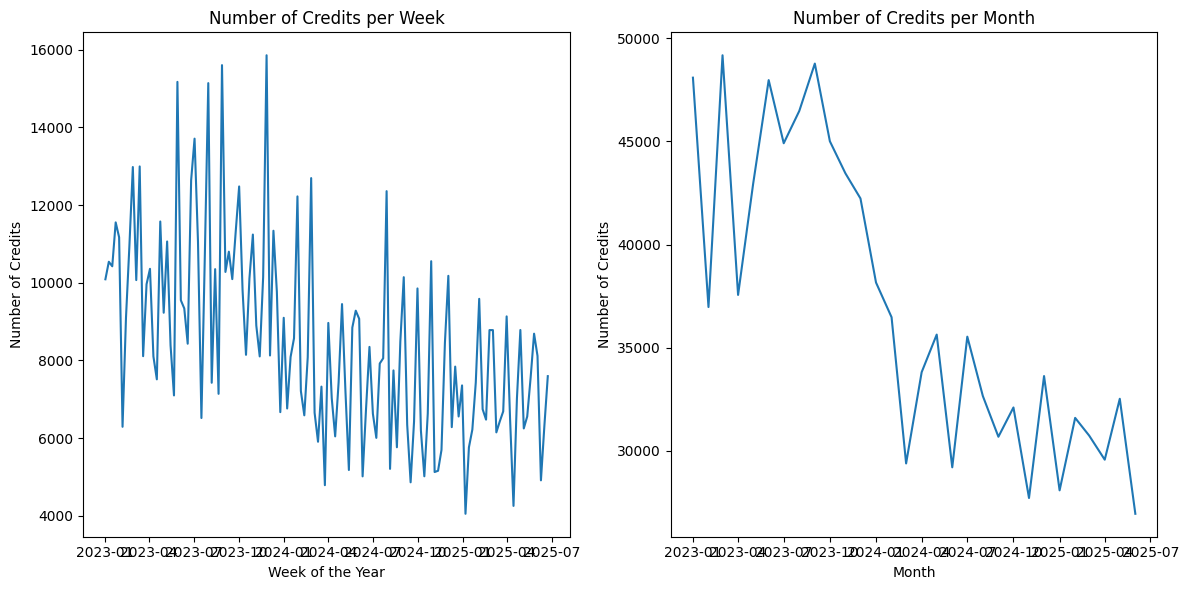

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['id_credito'].count()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['id_credito'].count()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('Number of Credits')
plt.title('Number of Credits per Month')

plt.tight_layout()
plt.show()


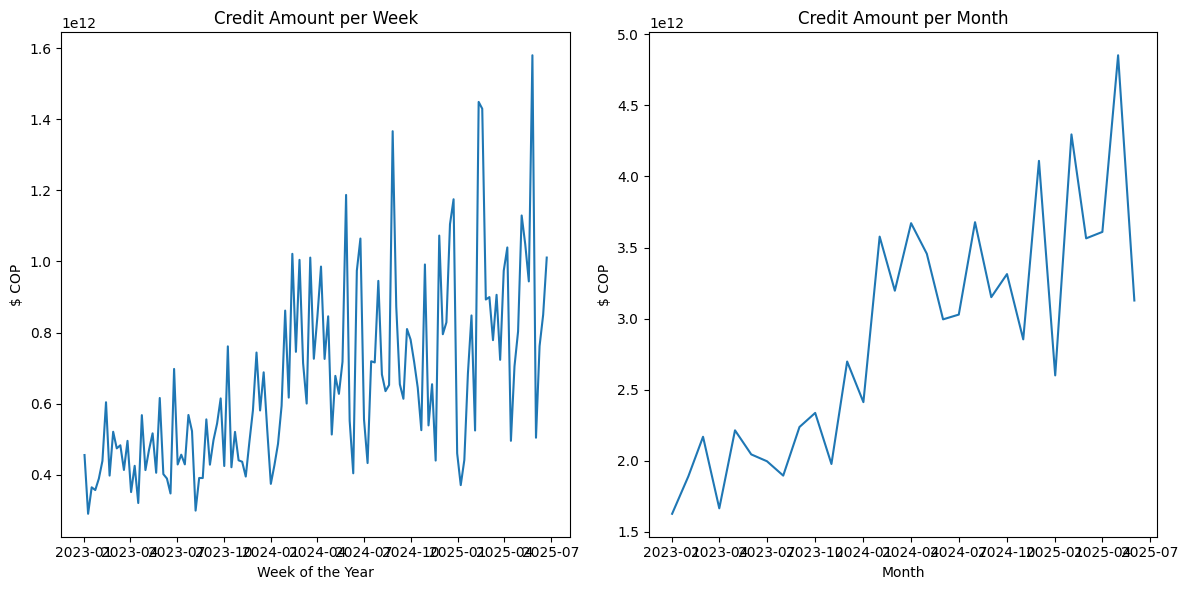

In [ ]:

df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].sum()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].sum()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Credit Amount per Month')

plt.tight_layout()
plt.show()


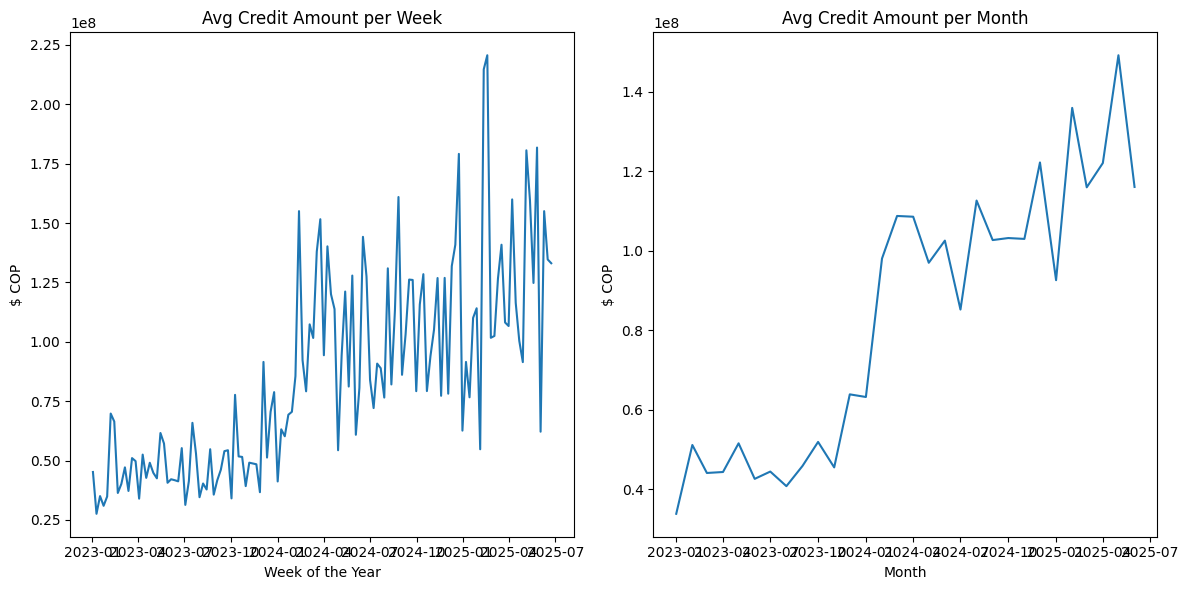

In [ ]:
df_pandas['fecha_credito'] = pd.to_datetime(df_pandas['fecha_credito'])

# Calculate the week and month of each credit
df_pandas['week'] = df_pandas['fecha_credito'].dt.to_period('W').dt.start_time
df_pandas['month'] = df_pandas['fecha_credito'].dt.to_period('M').dt.start_time

# Group by week and count the number of credits
weekly_credits = df_pandas.groupby('week')['valor_credito'].mean()

# Group by month and count the number of credits
monthly_credits = df_pandas.groupby('month')['valor_credito'].mean()

# Plotting
plt.figure(figsize=(12, 6))

# Weekly plot
plt.subplot(1, 2, 1)
plt.plot(weekly_credits.index, weekly_credits.values)
plt.xlabel('Week of the Year')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Week')

# Monthly plot
plt.subplot(1, 2, 2)
plt.plot(monthly_credits.index, monthly_credits.values)
plt.xlabel('Month')
plt.ylabel('$ COP')
plt.title('Avg Credit Amount per Month')

plt.tight_layout()
plt.show()


In [ ]:
df_pandas.columns

Index(['id_credito', 'fecha_credito', 'cod_municipio', 'tipo_cartera',
       'tipo_intermediario', 'tipo_productor', 'tipo_beneficiario',
       'tipo_persona', 'sexo', 'cod_destino', 'linea_credito', 'cadena',
       'eslabon_cadena', 'valor_credito', 'valor_inversion', 'plazo',
       'periodo_gracia', 'cuotas', 'cuotas_capital', 'tasa_indexacion',
       'periodicidad_tasa_indexacion', 'puntos_adicionales', 'garantia_fag',
       'nombre_programa', 'indicador_lec', 'valor_subsidio', 'nuevo',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'tasa_indexacion_valor', 'tasa_credito', 'week',
       'month'],
      dtype='object')

In [ ]:
df_pandas = df_pandas[df_pandas['linea_credito']!='Normalización de Cartera']

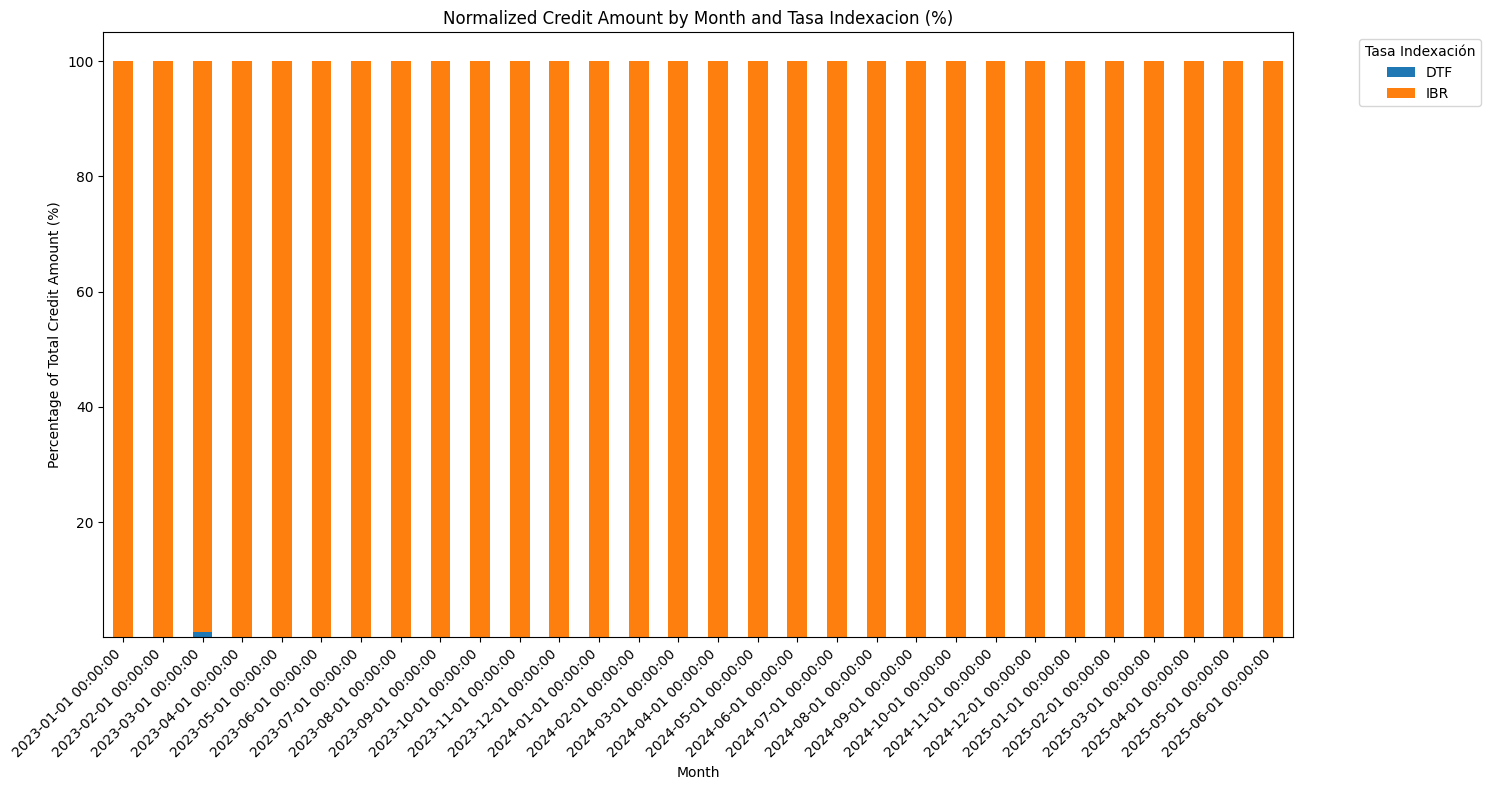

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tasa_indexacion'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tasa_indexacion', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tasa Indexacion (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tasa Indexación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

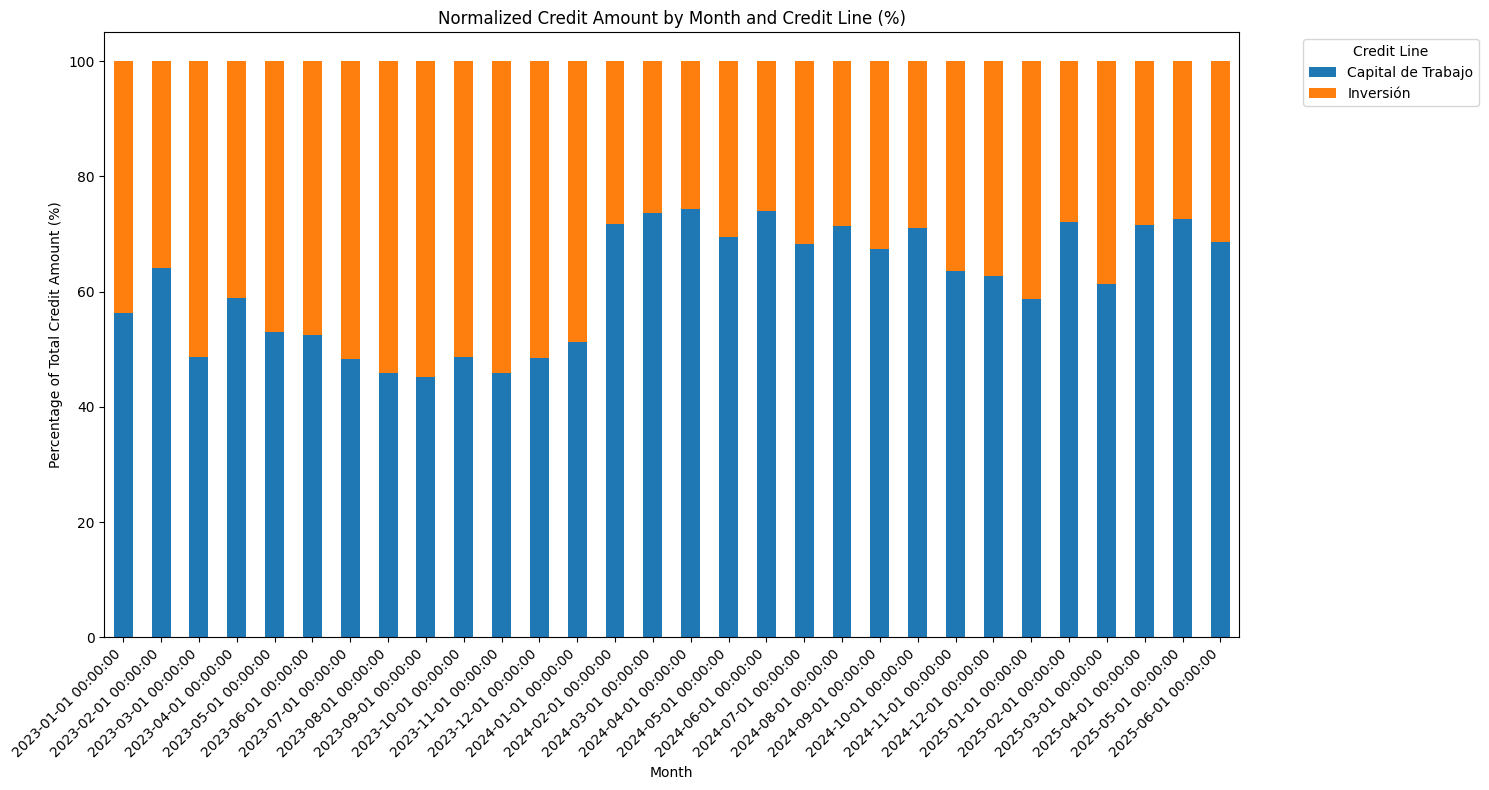

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'linea_credito'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='linea_credito', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Credit Line (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Credit Line', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

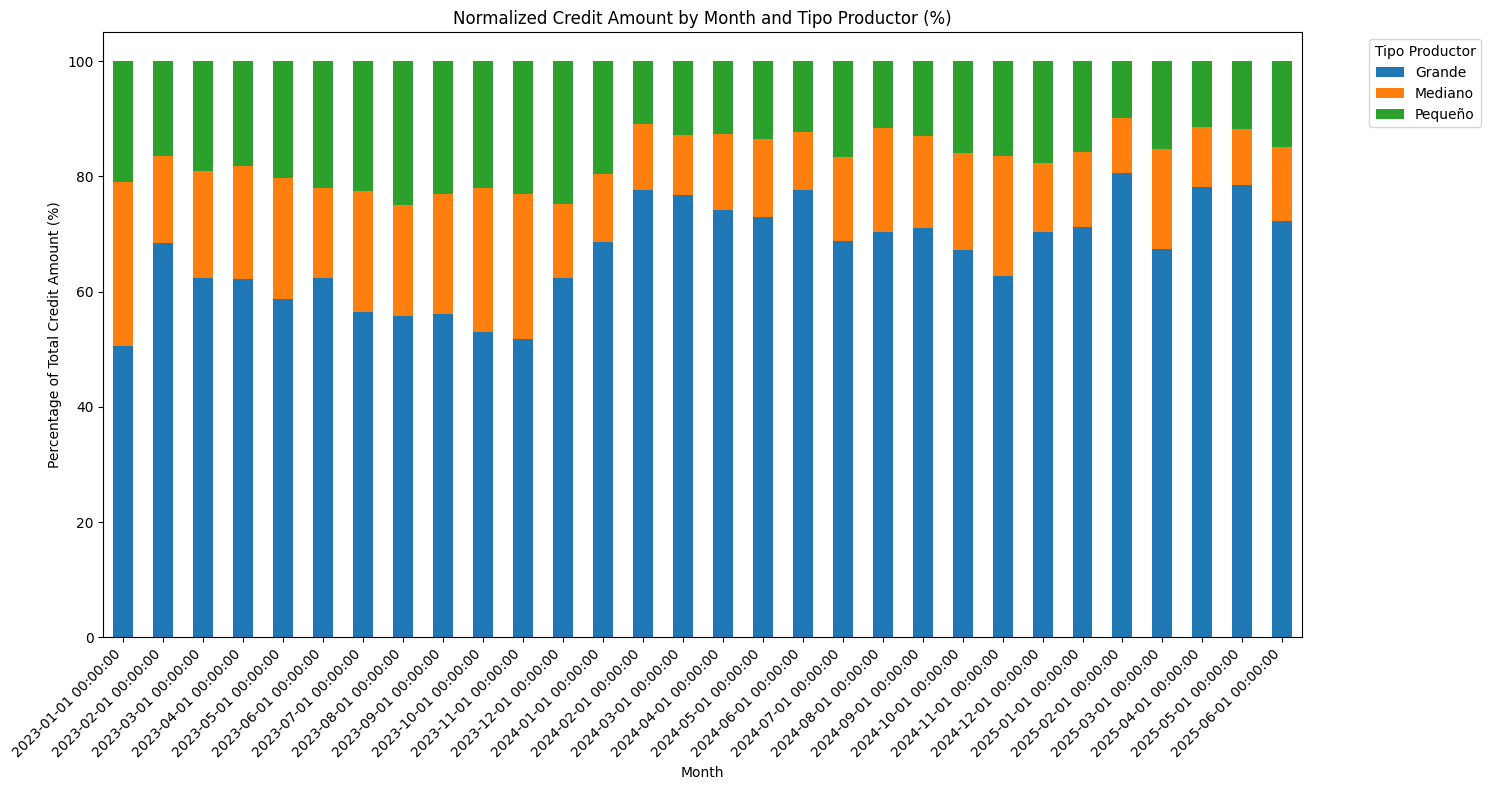

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_productor'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_productor', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Productor (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Productor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

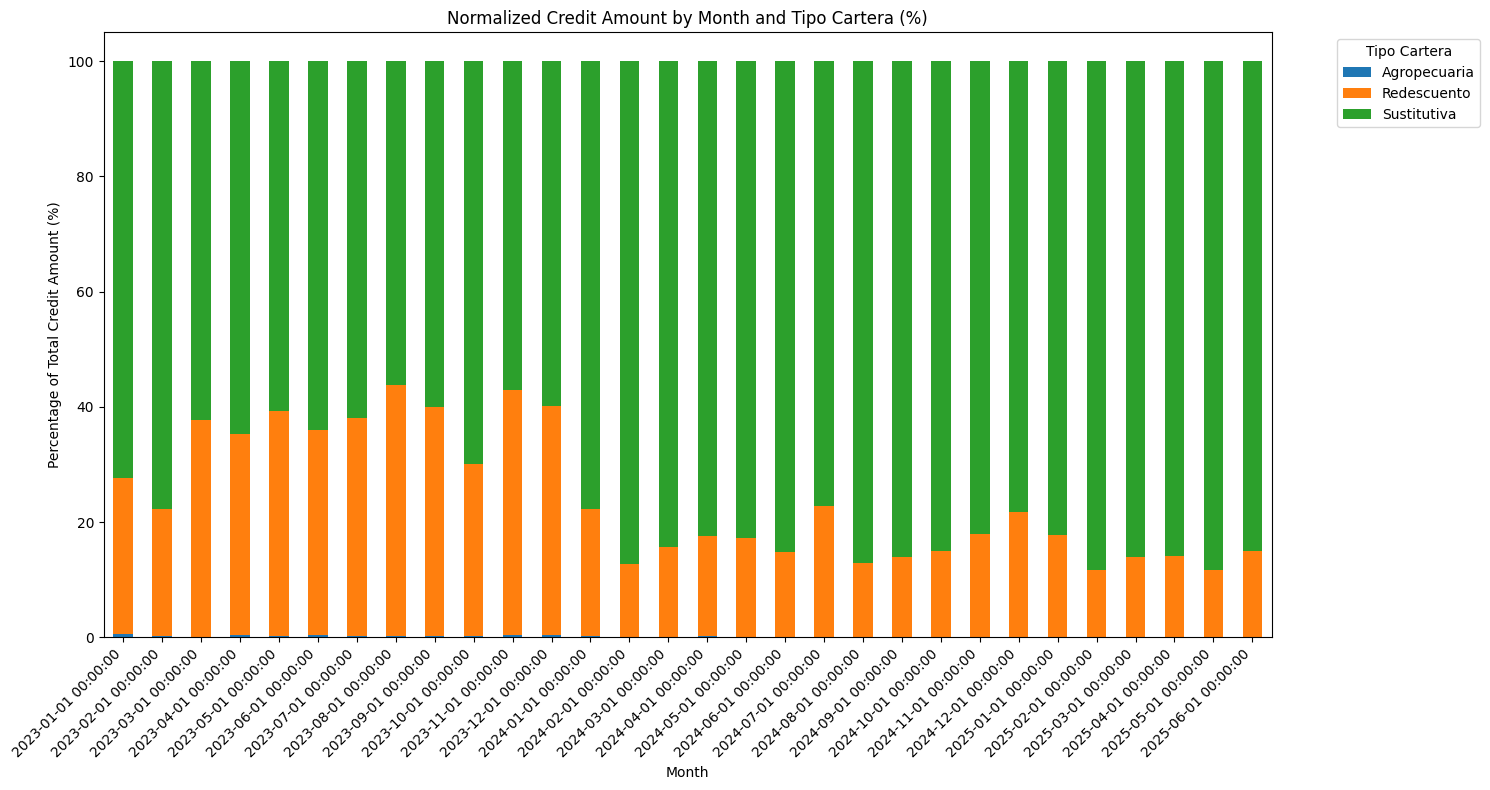

In [ ]:
# Group by month and categorical variable, summing valor_credito
grouped_data = df_pandas.groupby(['month', 'tipo_cartera'])['valor_credito'].sum().reset_index()

# Pivot the data to get months as index and categorical variable as columns
pivot_data = grouped_data.pivot(index='month', columns='tipo_cartera', values='valor_credito').fillna(0)

# Normalize the data to 100%
normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

# Plotting the stacked bar chart
ax = normalized_data.plot(kind='bar', stacked=True, figsize=(15, 8))

plt.title('Normalized Credit Amount by Month and Tipo Cartera (%)')
plt.xlabel('Month')
plt.ylabel('Percentage of Total Credit Amount (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo Cartera', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# IBR

In [ ]:
df_ibr = df_pandas[df_pandas['linea_credito']!='Normalización de Cartera']
df_ibr = df_ibr[df_ibr['tasa_indexacion']=='IBR']

In [ ]:
df_ibr.groupby('linea_credito').count()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,week,month
linea_credito,,,,,,,,,,,,,,,,,,,,,
Capital de Trabajo,496952,496952,496952,496952,496952,496952,496952,496952,496952,496952,...,496952,496952,496952,496952,496952,496952,460384,460384,496952,496952
Inversión,497988,497988,497988,497988,497988,497988,497988,497988,497988,497988,...,497988,497988,497988,497988,497988,497988,452524,452524,497988,497988


**Variables relevantes:**
* Cantidad prestada por redescuento
* Cantidad prestada
* Préstamos
* Préstamos por redescuento
* Préstamos a pequeños productores, etc
* Préstamos rurales
* Préstamos por género
* Préstamos
* Tasa
* Puntos adicionales
* Préstamos con LEC
* Préstamos con garantías más altas
* Prestamos a agropecuarios

## Mensual

In [ ]:
df_ibr_agg_month = df_ibr.groupby('month').apply(lambda group: pd.Series({
    # Generales
    'valor_credito_sum': group['valor_credito'].sum(),
    'creditos_count': group['id_credito'].count(),
    'creditos_avg': group['valor_credito'].mean(),

    # Cartera
    'cartera_redescuento_count': (group['tipo_cartera'] == 'Redescuento').sum(),
    'valor_credito_redescuento_sum': group.loc[group['tipo_cartera'] == 'Redescuento', 'valor_credito'].sum(),
    'valor_credito_redescuento_avg': group.loc[group['tipo_cartera'] == 'Redescuento', 'valor_credito'].mean(),

    'cartera_sustitutiva_count': (group['tipo_cartera'] == 'Sustitutiva').sum(),
    'valor_credito_sustitutiva_sum': group.loc[group['tipo_cartera'] == 'Sustitutiva', 'valor_credito'].sum(),
    'valor_credito_sustitutiva_avg': group.loc[group['tipo_cartera'] == 'Sustitutiva', 'valor_credito'].mean(),

    # Productores
    'grande_productor_count': (group['tipo_productor'] == 'Grande').sum(),
    'pequeno_productor_count': (group['tipo_productor'] == 'Pequeño').sum(),
    'valor_credito_pequeno_productor_sum': group.loc[group['tipo_productor'] == 'Pequeño', 'valor_credito'].sum(),
    'valor_credito_pequeno_productor_avg': group.loc[group['tipo_productor'] == 'Pequeño', 'valor_credito'].mean(),

    'ppib_productor_count': (group['tipo_productor'] == 'Pequeño ppib').sum(),
    'valor_credito_ppib_productor_sum': group.loc[group['tipo_productor'] == 'Pequeño ppib', 'valor_credito'].sum(),
    'valor_credito_ppib_productor_avg': group.loc[group['tipo_productor'] == 'Pequeño ppib', 'valor_credito'].mean(),

    # Tipo municipio
    'rural_count': (group['tipo_municipio'] == 'Rural').sum(),
    'rural_disperso_count': (group['tipo_municipio'] == 'Rural disperso').sum(),
    'valor_credito_rural_sum': group.loc[group['tipo_municipio'] == 'Rural', 'valor_credito'].sum(),
    'valor_credito_rural_avg': group.loc[group['tipo_municipio'] == 'Rural', 'valor_credito'].mean(),

    # LEC
    'lec_count': (group['indicador_lec'] == 1).sum(),
    'valor_credito_lec_sum': group.loc[group['indicador_lec'] == 1, 'valor_credito'].sum(),
    'valor_credito_lec_avg': group.loc[group['indicador_lec'] == 1, 'valor_credito'].mean(),

    # Sexo
    'hombre_count': (group['sexo'] == 'Hombre').sum(),
    'mujer_count': (group['sexo'] == 'Mujer').sum(),
    'valor_credicto_hombre_avg': group.loc[group['sexo'] == 'Hombre', 'valor_credito'].mean(),
    'valor_credito_mujer_avg': group.loc[group['sexo'] == 'Mujer', 'valor_credito'].mean(),
    'valor_credito_hombre_sum': group.loc[group['sexo'] == 'Hombre', 'valor_credito'].sum(),
    'valor_credito_mujer_sum': group.loc[group['sexo'] == 'Mujer', 'valor_credito'].sum(),

    # Intermediario
    'banco_count': (group['tipo_intermediario'] == 'Banco').sum(),
    'valor_inversion_banco_avg': group.loc[group['tipo_intermediario'] == 'Banco', 'valor_inversion'].mean(),
    'valor_inversion_banco_sum': group.loc[group['tipo_intermediario'] == 'Banco', 'valor_inversion'].sum(),

    # Eslabón
    'produccion_count': (group['eslabon_cadena'] == 'Producción').sum(),
    'transformacion_count': (group['eslabon_cadena'] == 'Transformación').sum(),
    'comercializacion_count': (group['eslabon_cadena'] == 'Comercialización').sum(),
    'valor_credito_produccion_avg': group.loc[group['eslabon_cadena'] == 'Producción', 'valor_credito'].mean(),
    'valor_credito_transformacion_avg': group.loc[group['eslabon_cadena'] == 'Transformación', 'valor_credito'].mean(),

    # Tasas
    'tasa_credito_avg': group['tasa_credito'].mean(),
    'tasa_indexacion_avg': group['tasa_indexacion_valor'].mean(),
    'tasa_indexacion_first': group['tasa_indexacion_valor'].iloc[0],
    'tasa_indexacion_last': group['tasa_indexacion_valor'].iloc[-1],
    'puntos_adicionales_avg': group['puntos_adicionales'].mean(),

    # Nuevo
    'nuevo_count': (group['nuevo'] == 1).sum(),
    'nuevo_sum': group.loc[group['nuevo'] == 1, 'valor_credito'].sum(),
    'nuevo_avg': group.loc[group['nuevo'] == 1, 'valor_credito'].mean()
})).reset_index()

df_ibr_agg_month.head()


/tmp/ipython-input-1983169938.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ibr_agg_month = df_ibr.groupby('month').apply(lambda group: pd.Series({


,month,valor_credito_sum,creditos_count,creditos_avg,cartera_redescuento_count,valor_credito_redescuento_sum,valor_credito_redescuento_avg,cartera_sustitutiva_count,valor_credito_sustitutiva_sum,valor_credito_sustitutiva_avg,...,valor_credito_produccion_avg,valor_credito_transformacion_avg,tasa_credito_avg,tasa_indexacion_avg,tasa_indexacion_first,tasa_indexacion_last,puntos_adicionales_avg,nuevo_count,nuevo_sum,nuevo_avg
0,2023-01-01,1.512751e+12,43871.0,3.448180e+07,25161.0,4.095532e+11,1.627730e+07,18674.0,1.093721e+12,5.856921e+07,...,2.397895e+07,3.464085e+08,35.012107,12.855749,12.869376,12.125933,14.341569,13203.0,1.788118e+11,1.354327e+07
1,2023-02-01,1.694876e+12,35019.0,4.839875e+07,22154.0,3.729101e+11,1.683263e+07,12852.0,1.317844e+12,1.025400e+08,...,3.190082e+07,3.676821e+08,33.239313,12.955971,12.701753,12.560955,10.631333,9540.0,1.848927e+11,1.938078e+07
2,2023-03-01,1.966381e+12,45647.0,4.307798e+07,32550.0,7.450919e+11,2.289069e+07,13083.0,1.218356e+12,9.312514e+07,...,3.013749e+07,4.942194e+08,28.635925,12.831371,12.699239,12.552039,12.057269,14731.0,2.682913e+11,1.821270e+07
3,2023-04-01,1.489501e+12,34572.0,4.308402e+07,22011.0,5.198053e+11,2.361571e+07,12548.0,9.635103e+11,7.678597e+07,...,3.094849e+07,3.797550e+08,25.087085,13.088254,12.869376,12.827625,7.647480,10463.0,1.995698e+11,1.907386e+07
4,2023-05-01,1.822802e+12,39840.0,4.575307e+07,29110.0,7.128446e+11,2.448796e+07,10716.0,1.105159e+12,1.031317e+08,...,3.340968e+07,3.167564e+08,22.405802,13.229954,13.003278,13.062416,6.441398,11358.0,2.314321e+11,2.037613e+07


In [ ]:
df_ibr_agg_month = df_ibr_agg_month.sort_values('month')
df_ibr_agg_month['tasa_indexacion_lag'] = df_ibr_agg_month['tasa_indexacion_first'].shift(1)

In [ ]:
# Calculate percentage columns for counts
for col in df_ibr_agg_month.columns:
    if '_count' in col and col != 'creditos_count':
        df_ibr_agg_month[col + '_pct'] = (df_ibr_agg_month[col] / df_ibr_agg_month['creditos_count']) * 100
    elif '_sum' in col and col != 'valor_credito_sum':
        df_ibr_agg_month[col + '_pct'] = (df_ibr_agg_month[col] / df_ibr_agg_month['valor_credito_sum']) * 100


In [ ]:
df_ibr_agg_month[['month','creditos_count','hombre_count_pct','mujer_count_pct','cartera_redescuento_count_pct','cartera_sustitutiva_count_pct','valor_credito_redescuento_sum_pct','valor_credito_sustitutiva_sum_pct']]

,month,creditos_count,hombre_count_pct,mujer_count_pct,cartera_redescuento_count_pct,cartera_sustitutiva_count_pct,valor_credito_redescuento_sum_pct,valor_credito_sustitutiva_sum_pct
0,2023-01-01,43871.0,58.368854,37.179458,57.352237,42.565704,27.073405,72.300157
1,2023-02-01,35019.0,57.383135,33.164853,63.262800,36.700077,22.002207,77.754589
2,2023-03-01,45647.0,60.157294,35.147983,71.308082,28.661248,37.891541,61.959331
3,2023-04-01,34572.0,60.430406,34.467199,63.667129,36.295268,34.897951,64.686793
4,2023-05-01,39840.0,59.643574,34.528112,73.067269,26.897590,39.107075,60.629672
5,2023-06-01,44334.0,59.570533,35.701719,68.117021,31.774710,35.577862,63.986382
6,2023-07-01,40838.0,57.987659,37.342671,60.997111,38.691905,37.845518,61.874614
7,2023-08-01,42692.0,58.247447,36.847653,63.482620,36.156657,43.642614,56.156127
8,2023-09-01,44661.0,58.164842,36.956181,66.167350,33.568438,39.623290,60.070241
9,2023-10-01,41524.0,56.576919,38.517484,63.787207,35.548117,29.833335,69.843388


## Mensual (Solo Mediano y Pequeño Productor)

In [ ]:
df_ibr_smes = df_ibr[df_ibr['tipo_productor'].isin(['Pequeño','Mediano'])]
df_ibr_smes.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,week,month
0,2350103751,2023-01-05,5887,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253050,...,0,True,5,ANTIOQUIA,YARUMAL,Intermedio,12.869376,17.917881,2023-01-02,2023-01-01
1,2350127280,2023-01-30,52083,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,900001,...,0,False,52,NARIÑO,BELÉN,Intermedio,12.633951,17.861196,2023-01-30,2023-01-01
2,2302529983,2023-01-30,25126,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NA,408011,...,0,True,25,CUNDINAMARCA,CAJICÁ,Ciudades y aglomeraciones,12.547581,23.603404,2023-01-30,2023-01-01
3,2350117950,2023-01-20,68245,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253000,...,0,True,68,SANTANDER,EL GUACAMAYO,Rural disperso,12.827946,17.875535,2023-01-16,2023-01-01
4,2350104346,2023-01-05,41006,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,347050,...,0,False,41,HUILA,ACEVEDO,Rural disperso,12.869376,17.917881,2023-01-02,2023-01-01


In [ ]:
df_ibr_agg_month_smes = df_ibr_smes.groupby('month').apply(lambda group: pd.Series({
    # Generales
    'valor_credito_sum': group['valor_credito'].sum(),
    'creditos_count': group['id_credito'].count(),
    'creditos_avg': group['valor_credito'].mean(),

    # Cartera
    'cartera_redescuento_count': (group['tipo_cartera'] == 'Redescuento').sum(),
    'valor_credito_redescuento_sum': group.loc[group['tipo_cartera'] == 'Redescuento', 'valor_credito'].sum(),
    'valor_credito_redescuento_avg': group.loc[group['tipo_cartera'] == 'Redescuento', 'valor_credito'].mean(),

    'cartera_sustitutiva_count': (group['tipo_cartera'] == 'Sustitutiva').sum(),
    'valor_credito_sustitutiva_sum': group.loc[group['tipo_cartera'] == 'Sustitutiva', 'valor_credito'].sum(),
    'valor_credito_sustitutiva_avg': group.loc[group['tipo_cartera'] == 'Sustitutiva', 'valor_credito'].mean(),

    # Productores
    'grande_productor_count': (group['tipo_productor'] == 'Grande').sum(),
    'pequeno_productor_count': (group['tipo_productor'] == 'Pequeño').sum(),
    'valor_credito_pequeno_productor_sum': group.loc[group['tipo_productor'] == 'Pequeño', 'valor_credito'].sum(),
    'valor_credito_pequeno_productor_avg': group.loc[group['tipo_productor'] == 'Pequeño', 'valor_credito'].mean(),

    # Tipo municipio
    'rural_count': (group['tipo_municipio'].isin(['Rural','Rural disperso'])).sum(),
    'rural_disperso_count': (group['tipo_municipio'] == 'Rural disperso').sum(),
    'valor_credito_rural_sum': group.loc[group['tipo_municipio'] == 'Rural', 'valor_credito'].sum(),
    'valor_credito_rural_avg': group.loc[group['tipo_municipio'] == 'Rural', 'valor_credito'].mean(),

    # LEC
    'lec_count': (group['indicador_lec'] == 1).sum(),
    'valor_credito_lec_sum': group.loc[group['indicador_lec'] == 1, 'valor_credito'].sum(),
    'valor_credito_lec_avg': group.loc[group['indicador_lec'] == 1, 'valor_credito'].mean(),

    # Sexo
    'hombre_count': (group['sexo'] == 'Hombre').sum(),
    'mujer_count': (group['sexo'] == 'Mujer').sum(),
    'valor_credicto_hombre_avg': group.loc[group['sexo'] == 'Hombre', 'valor_credito'].mean(),
    'valor_credito_mujer_avg': group.loc[group['sexo'] == 'Mujer', 'valor_credito'].mean(),
    'valor_credito_hombre_sum': group.loc[group['sexo'] == 'Hombre', 'valor_credito'].sum(),
    'valor_credito_mujer_sum': group.loc[group['sexo'] == 'Mujer', 'valor_credito'].sum(),

    # Intermediario
    'banco_count': (group['tipo_intermediario'] == 'Banco').sum(),
    'valor_inversion_banco_avg': group.loc[group['tipo_intermediario'] == 'Banco', 'valor_inversion'].mean(),
    'valor_inversion_banco_sum': group.loc[group['tipo_intermediario'] == 'Banco', 'valor_inversion'].sum(),

    # Eslabón
    'produccion_count': (group['eslabon_cadena'] == 'Producción').sum(),
    'transformacion_count': (group['eslabon_cadena'] == 'Transformación').sum(),
    'comercializacion_count': (group['eslabon_cadena'] == 'Comercialización').sum(),
    'valor_credito_produccion_avg': group.loc[group['eslabon_cadena'] == 'Producción', 'valor_credito'].mean(),
    'valor_credito_transformacion_avg': group.loc[group['eslabon_cadena'] == 'Transformación', 'valor_credito'].mean(),

    # Tasas
    'tasa_credito_avg': group['tasa_credito'].mean(),
    'tasa_indexacion_avg': group['tasa_indexacion_valor'].mean(),
    'tasa_indexacion_first': group['tasa_indexacion_valor'].iloc[0],
    'tasa_indexacion_last': group['tasa_indexacion_valor'].iloc[-1],
    'puntos_adicionales_avg': group['puntos_adicionales'].mean(),

    # Nuevo
    'nuevo_count': (group['nuevo'] == 1).sum(),
    'nuevo_sum': group.loc[group['nuevo'] == 1, 'valor_credito'].sum(),
    'nuevo_avg': group.loc[group['nuevo'] == 1, 'valor_credito'].mean()
})).reset_index()

df_ibr_agg_month_smes.head()

/tmp/ipython-input-15825877.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ibr_agg_month_smes = df_ibr_smes.groupby('month').apply(lambda group: pd.Series({


,month,valor_credito_sum,creditos_count,creditos_avg,cartera_redescuento_count,valor_credito_redescuento_sum,valor_credito_redescuento_avg,cartera_sustitutiva_count,valor_credito_sustitutiva_sum,valor_credito_sustitutiva_avg,...,valor_credito_produccion_avg,valor_credito_transformacion_avg,tasa_credito_avg,tasa_indexacion_avg,tasa_indexacion_first,tasa_indexacion_last,puntos_adicionales_avg,nuevo_count,nuevo_sum,nuevo_avg
0,2023-01-01,7.487025e+11,42826.0,1.748243e+07,25082.0,3.581159e+11,1.427781e+07,17712.0,3.874075e+11,2.187260e+07,...,1.544230e+07,8.590880e+07,34.869813,12.656860,12.869376,12.125933,14.547180,13167.0,1.549640e+11,1.176912e+07
1,2023-02-01,5.335728e+11,32260.0,1.653977e+07,21975.0,3.114586e+11,1.417331e+07,10278.0,2.203085e+11,2.143496e+07,...,1.518146e+07,5.574576e+07,34.008623,12.835176,12.701753,12.560955,10.974812,9338.0,1.275617e+11,1.366049e+07
2,2023-03-01,7.447327e+11,43701.0,1.704155e+07,32120.0,4.613395e+11,1.436300e+07,11572.0,2.815152e+11,2.432727e+07,...,1.596108e+07,5.493825e+07,28.877832,12.773296,12.699239,12.552039,12.302854,14619.0,1.799553e+11,1.230968e+07
3,2023-04-01,5.642866e+11,33005.0,1.709700e+07,21737.0,3.395090e+11,1.561895e+07,11261.0,2.224733e+11,1.975609e+07,...,1.608070e+07,4.940706e+07,24.990333,12.913272,12.869376,12.827625,7.754283,10344.0,1.239373e+11,1.198157e+07
4,2023-05-01,7.527110e+11,37804.0,1.991088e+07,28826.0,5.191000e+11,1.800805e+07,8971.0,2.320251e+11,2.586390e+07,...,1.896493e+07,5.285606e+07,22.187459,13.046192,13.003278,13.062416,6.508269,11195.0,1.643103e+11,1.467711e+07


In [ ]:
df_ibr_agg_month_smes = df_ibr_agg_month_smes.sort_values('month')
df_ibr_agg_month_smes['tasa_indexacion_lag'] = df_ibr_agg_month_smes['tasa_indexacion_first'].shift(1)

In [ ]:
# Calculate percentage columns for counts
for col in df_ibr_agg_month_smes.columns:
    if '_count' in col and col != 'creditos_count':
        df_ibr_agg_month_smes[col + '_pct'] = (df_ibr_agg_month_smes[col] / df_ibr_agg_month_smes['creditos_count']) * 100
    elif '_sum' in col and col != 'valor_credito_sum':
        df_ibr_agg_month_smes[col + '_pct'] = (df_ibr_agg_month_smes[col] / df_ibr_agg_month_smes['valor_credito_sum']) * 100

In [ ]:
columns_to_keep_smes = [col for col in df_ibr_agg_month_smes.columns if "_pct" in col or "tasa" in col or "avg" in col or "month" in col]


In [ ]:
df_ibr_agg_month_smes = df_ibr_agg_month_smes[columns_to_keep_smes]

In [ ]:
df_ibr_agg_month_smes = df_ibr_agg_month_smes.fillna(0)

In [ ]:
df_ibr_agg_month_smes.columns

Index(['month', 'creditos_avg', 'valor_credito_redescuento_avg',
       'valor_credito_sustitutiva_avg', 'valor_credito_pequeno_productor_avg',
       'valor_credito_rural_avg', 'valor_credito_lec_avg',
       'valor_credicto_hombre_avg', 'valor_credito_mujer_avg',
       'valor_inversion_banco_avg', 'valor_credito_produccion_avg',
       'valor_credito_transformacion_avg', 'tasa_credito_avg',
       'tasa_indexacion_avg', 'tasa_indexacion_first', 'tasa_indexacion_last',
       'puntos_adicionales_avg', 'nuevo_avg', 'tasa_indexacion_lag',
       'cartera_redescuento_count_pct', 'valor_credito_redescuento_sum_pct',
       'cartera_sustitutiva_count_pct', 'valor_credito_sustitutiva_sum_pct',
       'grande_productor_count_pct', 'pequeno_productor_count_pct',
       'valor_credito_pequeno_productor_sum_pct', 'rural_count_pct',
       'rural_disperso_count_pct', 'valor_credito_rural_sum_pct',
       'lec_count_pct', 'valor_credito_lec_sum_pct', 'hombre_count_pct',
       'mujer_count_pct',

# Comparación en el tiempo

### Correlación

**Hipotesis**

> *Existe una correlación entre el IBR y otros aspectos de la financiación*



In [ ]:
columns_to_keep_smes = [col for col in df_ibr_agg_month.columns if "valor_credito" in col or "tasa" in col]
columns_to_keep_smes = [col for col not in df_ibr_agg_month.columns if "avg" in col]

df_ibr_agg_month_copy = df_ibr_agg_month.drop(["month"],axis=1).copy()
df_ibr_agg_month_copy = df_ibr_agg_month_copy[columns_to_keep_smes]

KeyError: "['month'] not in index"

In [ ]:
correlation_matrix_mes = df_ibr_agg_month_copy.corr()

In [ ]:
relevant_correlations_mes = correlation_matrix_mes[
    ['tasa_indexacion_first', 'tasa_indexacion_avg', 'tasa_indexacion_lag']
].loc[
    (correlation_matrix_mes['tasa_indexacion_first'].abs() > 0.4) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0.4) |
    (correlation_matrix_mes['tasa_indexacion_lag'].abs() > 0.4)
]

relevant_correlations_mes


In [ ]:
correlation_matrix_mes[
    ['tasa_indexacion_first', 'tasa_indexacion_avg', 'tasa_indexacion_lag']
].loc[
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0)
]

In [ ]:
correlation_matrix_mes[
    ['tasa_indexacion_first', 'tasa_indexacion_avg', 'tasa_indexacion_lag']
].loc[
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0.1) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0.1) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0.1)
]

### Comportamiento en el tiempo

In [ ]:
df_ibr_agg_month.reset_index(inplace=True)
df_ibr_agg_month['month'] = df_ibr_agg_month['month'].dt.strftime('%Y-%m')

In [ ]:
def compare_variables_over_time(df, date_column, var1_column, var2_column):
    """
    Compares two variables over time, plotting them on different y-axes.

    Args:
        df: DataFrame containing the data.
        date_column: Name of the date column (must be datetime objects).
        var1_column: Name of the first variable column.
        var2_column: Name of the second variable column.
    """

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot the first variable
    color = 'tab:red'
    ax1.set_xlabel('Month')
    ax1.set_ylabel(var1_column, color=color)
    ax1.plot(df[date_column], df[var1_column], color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Create a second y-axis
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel(var2_column, color=color)
    ax2.plot(df[date_column], df[var2_column], color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Rotate date labels for better readability (optional)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.title(f'Comparison of {var1_column} and {var2_column} Over Time')
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_stacked_bar_and_line(df, date_column, categorical_column, value_column, line_column, line_label):
    """
    Generates a plot with a stacked bar chart for a categorical variable
    and a line chart for another variable on a secondary axis, over time.

    Args:
        df: DataFrame containing the data.
        date_column: Name of the date column (must be datetime objects).
        categorical_column: Name of the categorical column for the stacked bar chart.
        value_column: Name of the value column to sum for the stacked bar chart.
        line_column: Name of the column for the line chart.
        line_label: Label for the line chart's y-axis.
    """

    # Group data for stacked bar chart
    grouped_data = df.groupby([date_column, categorical_column])[value_column].sum().reset_index()
    pivot_data = grouped_data.pivot(index=date_column, columns=categorical_column, values=value_column).fillna(0)
    normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

    # Prepare data for line chart (assuming df_ibr_agg_month has the line_column)
    line_data = df.groupby([date_column])[line_column].mean()

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 8))

    # Plot stacked bar chart
    normalized_data.plot(kind='bar', stacked=True, ax=ax1)
    ax1.set_ylabel(f'Percentage of Total {value_column} (%)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xlabel(date_column)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title=categorical_column, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Create a second y-axis for the line chart
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.plot(line_data.index.astype(str), line_data.values, color=color, marker='o') # Plotting against string dates for alignment
    ax2.set_ylabel(line_label, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Normalized {value_column} by {categorical_column} and {line_label} Over Time')
    plt.tight_layout()
    plt.show()



##### Tasa

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'tasa_credito_avg')

##### Productor

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'pequeno_productor_count_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_pequeno_productor_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_pequeno_productor_avg')


In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'grande_productor_count_pct')

In [ ]:
df_ibr['creditos'] = 1

plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_productor', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_productor', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

##### Sexo

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_mujer_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_mujer_avg')

In [ ]:
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'sexo', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'sexo', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

##### Rural

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'rural_count_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_rural_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_rural_avg')

In [ ]:
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_municipio', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_municipio', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

##### Cartera

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'cartera_redescuento_count_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_redescuento_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_redescuento_avg')

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'cartera_sustitutiva_count_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_sustitutiva_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'valor_credito_sustitutiva_avg')

In [ ]:
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_cartera', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_cartera', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

##### Nuevo

In [ ]:
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'nuevo_count_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'nuevo_sum_pct')
compare_variables_over_time(df_ibr_agg_month, 'month', 'tasa_indexacion_avg', 'nuevo_avg')

In [ ]:
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'nuevo', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'nuevo', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

### Correlación SMEs

In [ ]:
df_ibr_agg_month_copy_smes = df_ibr_agg_month_smes.drop(["month"],axis=1).copy()

In [ ]:
correlation_matrix_mes_smes = df_ibr_agg_month_copy_smes.corr()

In [ ]:
correlation_matrix_mes_smes = correlation_matrix_mes_smes[
    ['tasa_indexacion_first', 'tasa_indexacion_avg', 'tasa_indexacion_lag']
].loc[
    (correlation_matrix_mes['tasa_indexacion_first'].abs() > 0.4) |
    (correlation_matrix_mes['tasa_indexacion_avg'].abs() > 0.4) |
    (correlation_matrix_mes['tasa_indexacion_lag'].abs() > 0.4)
]

correlation_matrix_mes_smes

### Visualizaciones SMEs

In [ ]:
df_ibr_agg_month_smes.reset_index(inplace=True)
df_ibr_agg_month_smes['month'] = df_ibr_agg_month_smes['month'].dt.strftime('%Y-%m')

In [ ]:
def compare_variables_over_time(df, date_column, var1_column, var2_column):
    """
    Compares two variables over time, plotting them on different y-axes.

    Args:
        df: DataFrame containing the data.
        date_column: Name of the date column (must be datetime objects).
        var1_column: Name of the first variable column.
        var2_column: Name of the second variable column.
    """

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot the first variable
    color = 'tab:red'
    ax1.set_xlabel('Month')
    ax1.set_ylabel(var1_column, color=color)
    ax1.plot(df[date_column], df[var1_column], color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Create a second y-axis
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel(var2_column, color=color)
    ax2.plot(df[date_column], df[var2_column], color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Rotate date labels for better readability (optional)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.title(f'Comparison of {var1_column} and {var2_column} Over Time')
    plt.tight_layout()
    plt.show()


In [ ]:
compare_variables_over_time(df_ibr_agg_month_smes, 'month', 'tasa_indexacion_avg', 'tasa_credito_avg')
compare_variables_over_time(df_ibr_agg_month_smes, 'month', 'tasa_indexacion_avg', 'valor_credito_sustitutiva_sum_pct')
compare_variables_over_time(df_ibr_agg_month_smes, 'month', 'tasa_indexacion_avg', 'cartera_sustitutiva_count_pct')
compare_variables_over_time(df_ibr_agg_month_smes, 'month', 'tasa_indexacion_avg', 'valor_credito_rural_sum_pct')

In [ ]:
df_ibr_smes_plot = df_ibr_smes.copy()
df_ibr_smes_plot['tipo_municipio'] = df_ibr_smes_plot['tipo_municipio'].replace({
    'Rural disperso': 'Rural',
    'Intermedio': 'Rural',
    'Ciudades y aglomeraciones': 'Urbano'
})


In [ ]:
def plot_stacked_bar_and_line(df, date_column, categorical_column, value_column, line_column, line_label):
    """
    Generates a plot with a stacked bar chart for a categorical variable
    and a line chart for another variable on a secondary axis, over time.

    Args:
        df: DataFrame containing the data.
        date_column: Name of the date column (must be datetime objects).
        categorical_column: Name of the categorical column for the stacked bar chart.
        value_column: Name of the value column to sum for the stacked bar chart.
        line_column: Name of the column for the line chart.
        line_label: Label for the line chart's y-axis.
    """

    # Group data for stacked bar chart
    grouped_data = df.groupby([date_column, categorical_column])[value_column].sum().reset_index()
    pivot_data = grouped_data.pivot(index=date_column, columns=categorical_column, values=value_column).fillna(0)
    normalized_data = pivot_data.divide(pivot_data.sum(axis=1), axis=0) * 100

    # Prepare data for line chart (assuming df_ibr_agg_month has the line_column)
    line_data = df.groupby([date_column])[line_column].mean()

    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 8))

    # Plot stacked bar chart
    normalized_data.plot(kind='bar', stacked=True, ax=ax1)
    ax1.set_ylabel(f'Percentage of Total {value_column} (%)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xlabel(date_column)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title=categorical_column, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Create a second y-axis for the line chart
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.plot(line_data.index.astype(str), line_data.values, color=color, marker='o') # Plotting against string dates for alignment
    ax2.set_ylabel(line_label, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Normalized {value_column} by {categorical_column} and {line_label} Over Time')
    plt.tight_layout()
    plt.show()

plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_municipio', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')

In [ ]:
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'tipo_municipio', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')

In [ ]:
df_ibr['es_credito'] = 1
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_productor', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_productor', 'es_credito'   , 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'tipo_cartera', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')

In [ ]:
df_ibr['creditos'] = 1

plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_cartera', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'tipo_cartera', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')

In [ ]:
df_ibr_smes['creditos'] = 1
plot_stacked_bar_and_line(df_ibr_smes.copy(), 'month', 'tipo_cartera', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr_smes.copy(), 'month', 'tipo_cartera', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'indicador_lec', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'nuevo', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'lec', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr_smes_plot.copy(), 'month', 'eslabon_cadena', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
df_ibr['creditos'] = 1
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'linea_credito', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr.copy(), 'month', 'linea_credito', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
df_ibr_smes['creditos'] = 1
plot_stacked_bar_and_line(df_ibr_smes.copy(), 'month', 'linea_credito', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr_smes.copy(), 'month', 'linea_credito', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')


In [ ]:
df_ibr_plot = df_ibr.copy()
df_ibr_plot['tipo_municipio'] = df_ibr_plot['tipo_municipio'].replace({
    'Rural disperso': 'Rural',
    'Intermedio': 'Rural',
    'Ciudades y aglomeraciones': 'Urbano'
})


In [ ]:
df_ibr_plot['creditos'] = 1
plot_stacked_bar_and_line(df_ibr_plot.copy(), 'month', 'tipo_municipio', 'valor_credito', 'tasa_indexacion_valor', 'Average IBR (%)')
plot_stacked_bar_and_line(df_ibr_plot.copy(), 'month', 'tipo_municipio', 'creditos', 'tasa_indexacion_valor', 'Average IBR (%)')


# Qué pasó en el 2024?

[Incremento del 50% en colocaciones](https://www.finagro.com.co/noticias/articulos/2024-finagro-alcanzo-resultados-historicos-tras-desembolsar-mas-394-billones-credito-fomento). Sin embargo, disminuyeron en cantidad.

In [ ]:
df_ibr = df_pandas[df_pandas['tasa_indexacion']=='IBR']
df_ibr = df_ibr.reset_index(drop=True)
df_ibr['year'] = df_ibr['fecha_credito'].dt.year

In [ ]:
df_ibr.columns

In [ ]:
yearly_credits = df_ibr.groupby('year')['id_credito'].count()
yearly_credits_amount = df_ibr.groupby('year')['valor_credito'].sum()

# Plotting
plt.figure(figsize=(12, 6))

# count plot
plt.subplot(1, 2, 1)
plt.plot(yearly_credits.index, yearly_credits.values)
plt.xlabel('Year')
plt.ylim(0, 600000)
plt.ylabel('Number of Credits')
#add the data labels in the chart
plt.text(yearly_credits.index[0], yearly_credits.values[0], str(yearly_credits.values[0]), ha='center', va='bottom')
plt.text(yearly_credits.index[1], yearly_credits.values[1], str(yearly_credits.values[1]), ha='center', va='bottom')
plt.text(yearly_credits.index[2], yearly_credits.values[2], str(yearly_credits.values[2]), ha='center', va='bottom')
plt.title('Number of Credits per Year')

# amount plot
plt.subplot(1, 2, 2)
plt.plot(yearly_credits_amount.index, yearly_credits_amount.values)
plt.xlabel('Year')
plt.ylim(0, yearly_credits_amount.max()+1e13)
plt.ylabel('$ COP')
plt.title('Credit Amount per Year')

plt.tight_layout()
plt.show()


In [ ]:
df_pandas.columns

Preguntas a resolver:
* Qué cartera financió estos créditos?
* A quién iban dirigidos? Tipo productor, género, departamento, tipo persona
* Qué tipo de intermediario tienen?
* Pasó algo con las líneas especiales de credito?
* A qué tipo de municipio o departamento?

In [ ]:
df_ibr['year'] = df_ibr['fecha_credito'].dt.year

In [ ]:
def plot__bar_chart(df, year_column, category_column, value_column):
    """
    Plots a stacked bar chart of a categorical variable over time.

    Args:
        df: DataFrame containing the data.
        year_column: Name of the column representing the year.
        category_column: Name of the column representing the categorical variable.
    """
    # Group data by year and category
    grouped_data = df.groupby([year_column, category_column]).size().unstack()

    sum_data = df.groupby([year_column, category_column])[value_column].sum().unstack(fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

    # ---- Gráfico de conteo ----
    ax1 = grouped_data.plot(kind='bar', stacked=True, ax=axes[0], legend=False)
    axes[0].set_title('Distribución por conteo')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.0f', label_type='center', fontsize=8, color='white')

    # ---- Gráfico de suma ----
    ax2 = sum_data.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('Distribución por suma de credito')
    axes[1].set_xlabel('Año')
    axes[0].set_ylabel('Amount')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title=category_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    for container in ax2.containers:
        values_in_billions = [value / 1e12 for value in container.datavalues]
        ax2.bar_label(container, labels=[f'{value:.1f}B' for value in values_in_billions], label_type='center', fontsize=8, color='white')
    plt.show()


In [ ]:
def plot_stacked_bar_chart(df, year_column, category_column, value_column):
    """
    Plots a 100% stacked bar chart of a categorical variable over time.

    Args:
        df: DataFrame containing the data.
        year_column: Name of the column representing the year.
        category_column: Name of the column representing the categorical variable.
    """
    # Group data by year and category
    grouped_data = df.groupby([year_column, category_column]).size().unstack()
    grouped_data = grouped_data.div(grouped_data.sum(axis=1), axis=0) * 100

    sum_data = df.groupby([year_column, category_column])[value_column].sum().unstack(fill_value=0)
    sum_data = sum_data.div(sum_data.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # ---- Gráfico de conteo ----
    ax1 = grouped_data.plot(kind='bar', stacked=True, ax=axes[0], legend=False)
    axes[0].set_title('Distribución porcentual por conteo')
    axes[0].set_xlabel('Año')
    axes[0].set_ylabel('Porcentaje')
    axes[0].tick_params(axis='x', rotation=45)

    # ---- Gráfico de suma ----
    ax2 = sum_data.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('Distribución porcentual por suma de valor_credito')
    axes[1].set_xlabel('Año')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title=category_column, bbox_to_anchor=(1.05, 1), loc='upper left')

    # ---- Añadir etiquetas a ambos gráficos ----
    for ax in [ax1, ax2]:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, color='white')
    plt.show()


In [ ]:
plot__bar_chart(df_ibr, 'year', 'tipo_cartera', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'tipo_productor', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'tipo_intermediario', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'eslabon_cadena', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'tipo_municipio', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'sexo', 'valor_credito')
plot__bar_chart(df_ibr, 'year', 'indicador_lec', 'valor_credito')

In [ ]:
plot_stacked_bar_chart(df_ibr, 'year', 'tipo_cartera', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'tipo_productor', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'tipo_intermediario', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'eslabon_cadena', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'tipo_municipio', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'sexo', 'valor_credito')
plot_stacked_bar_chart(df_ibr, 'year', 'indicador_lec', 'valor_credito')

In [ ]:
import plotly.express as px

In [ ]:
def plot_treemap(df, year_column, type_column, value_column):
    """
    Plots a treemap showing the distribution of value_column across year and type_column,
    con valores formateados en billones (B).
    """
    df = df.copy()
    df['valor_billones'] = df[value_column] / 1e12  # Convertir a billones

    fig = px.treemap(
        df,
        path=[year_column, type_column],       # Jerarquía del treemap
        values='valor_billones',               # Usamos valores en billones
        color=year_column,
        color_discrete_sequence=px.colors.qualitative.Set2,
        title='Treemap por Año y Tipo de Productor (tamaño = valor_credito en Billones)'
    )

    fig.update_traces(
        texttemplate='%{label}<br>%{value:.2f}B<br>%{percentParent:.1%}',
        hovertemplate='<b>%{label}</b><br>Valor: %{value:.2f}B<br>%{percentParent:.1%}<extra></extra>'
    )

    fig.show()

In [ ]:
plot_treemap(df_ibr, 'year', 'tipo_productor', 'valor_credito')

In [ ]:
plot_treemap(df_ibr.query('year == 2023'), 'tipo_productor', 'tipo_cartera', 'valor_credito')
plot_treemap(df_ibr.query('year == 2024'), 'tipo_productor', 'tipo_cartera', 'valor_credito')

In [ ]:
plot_treemap(df_ibr.query('year == 2021'), 'tipo_productor', 'tipo_cartera', 'valor_credito')
plot_treemap(df_ibr.query('year == 2022'), 'tipo_productor', 'tipo_cartera', 'valor_credito')

In [ ]:
def plot_treemap_count(df, year_column, type_column, value_column):
    """
    Plots a treemap showing the distribution of value_column across year and type_column,
    con valores formateados en billones (B).
    """
    df = df.copy()
    df['valor_miles'] = df[value_column] / 1e3  # Convertir a miles

    fig = px.treemap(
        df,
        path=[year_column, type_column],       # Jerarquía del treemap
        values='valor_miles',               # Usamos valores en miles
        color=year_column,
        color_discrete_sequence=px.colors.qualitative.Set2,
        title='Treemap por Año y Tipo de Productor (tamaño = créditos en Miles)'
    )

    fig.update_traces(
        texttemplate='%{label}<br>%{value:.2f}K<br>%{percentParent:.1%}',
        hovertemplate='<b>%{label}</b><br>Valor: %{value:.2f}K<br>%{percentParent:.1%}<extra></extra>'
    )

    fig.show()

In [ ]:
plot_treemap_count(df_ibr.query('year == 2021'), 'tipo_productor', 'tipo_cartera', 'creditos')
plot_treemap_count(df_ibr.query('year == 2022'), 'tipo_productor', 'tipo_cartera', 'creditos')
plot_treemap_count(df_ibr.query('year == 2023'), 'tipo_productor', 'tipo_cartera', 'creditos')
plot_treemap_count(df_ibr.query('year == 2024'), 'tipo_productor', 'tipo_cartera', 'creditos')

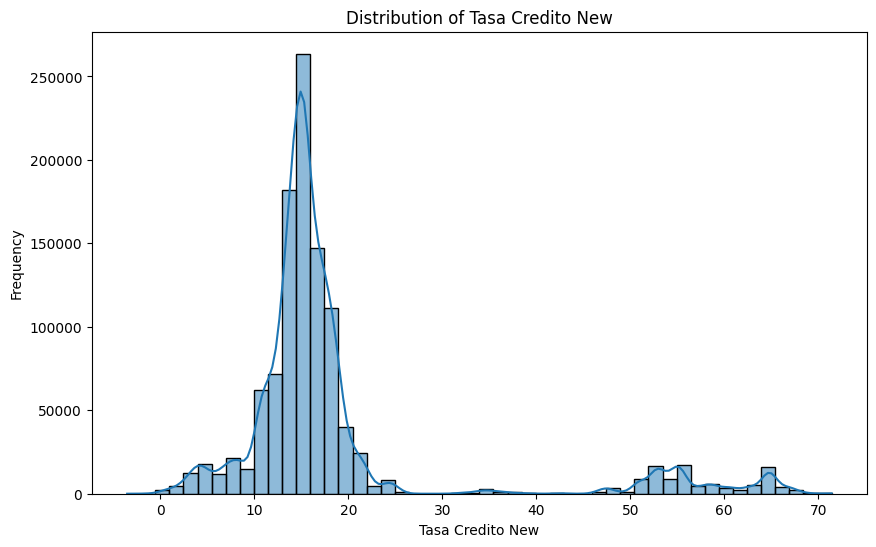